Isto é para descarregar a pasta zip com os ficheiros (depois aparecem nas pastas daqui):


In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!mkdir -p /content/drive/MyDrive/neuro_project_outputs

In [ ]:
import zipfile
import os

zip_name = "project_data.zip"
extract_dir = "/content/drive/MyDrive/neuro_project_outputs"

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

In [ ]:
import os

hc_img_dir = "/content/drive/MyDrive/neuro_project_outputs/imagens/HC"
pd_img_dir = "/content/drive/MyDrive/neuro_project_outputs/imagens/PD"

os.makedirs(hc_img_dir, exist_ok=True)
os.makedirs(pd_img_dir, exist_ok=True)

print("Pastas criadas com sucesso.")

**IR BUSCAR OS FICHEIROS QUE JÁ SE TIVEREM CORRIDO ANTES:**

In [ ]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

In [ ]:
!ls /content/drive/MyDrive/neuro_project_outputs/project_data/

In [ ]:
HC = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control"
PD = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD"

In [ ]:
%%capture
import os
import sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
  os.environ["LD_PRELOAD"] = "";
  os.environ["APPTAINER_BINDPATH"] = "/content,/tmp,/cvmfs"
  os.environ["MPLCONFIGDIR"] = "/content/matplotlib-mpldir"
  os.environ["LMOD_CMD"] = "/usr/share/lmod/lmod/libexec/lmod"
  !curl -J -O https://raw.githubusercontent.com/NeuroDesk/neurocommand/main/googlecolab_setup.sh
  !chmod +x googlecolab_setup.sh
  !./googlecolab_setup.sh
  os.environ["MODULEPATH"] = ':'.join(map(str, list(map(lambda x: os.path.join(os.path.abspath('/cvmfs/neurodesk.ardc.edu.au/neurodesk-modules/'), x),os.listdir('/cvmfs/neurodesk.ardc.edu.au/neurodesk-modules/')))))

In [ ]:
import lmod
await lmod.load('fsl/6.0.7.16')

In [ ]:
from IPython.display import display, Markdown
from ipyniivue import AnyNiivue
from nilearn import plotting


#**NEUROIMAGING PROJECT**
Group 4 - Bruno Comba Massano, 106195; Carolina da Conceição Araújo, 116176; David Cheira Rodrigues, 106247; Inês Palma Patraquim Godinho, 105927; Filipa Alexandre Cantante, 116027


This project aims to investigate structural and functional brain differences between a healthy control (HC) and a Parkinson’s disease (PD) subject.  
Structurally, we focus on subcortical morphology and the volumes of selected regions of interest.  
Functionally, we preprocess resting-state fMRI data, perform ICA, identify the Default Mode Network (DMN), and compare DMN connectivity strength between subjects.

### **Data description**
The dataset includes two participants from the OpenNeuro dataset:
- one healthy control (HC) - sub-MJF006-Control
- one Parkinson’s disease subject (PD) - sub-MJF002-PD

### **Analysis pipeline**
1. Structural MRI preprocessing  
-  Tissue and subcortical segmentation  
- Spatial normalisation to MNI space
- Volume extraction of selected subcortical structures  
2. Resting-state fMRI preprocessing  
- ICA and DMN identification using Yeo’s 7-network DMN template  
3. Subject comparison of subcortical volumes and DMN connectivity strength

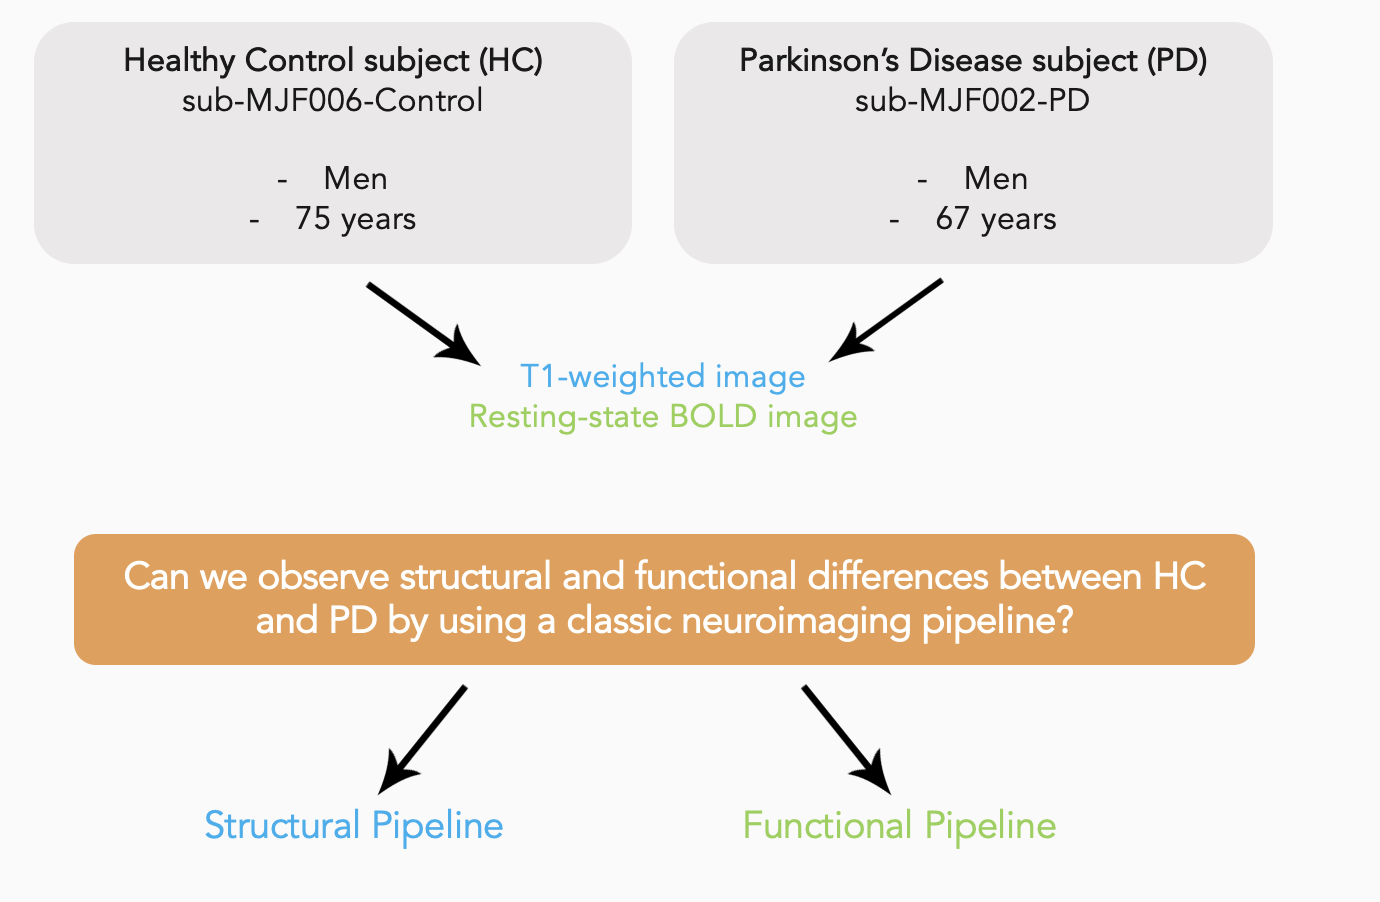

## **1. Structural MRI Preprocessing.**

In this first section, we prepare the anatomical **T1-weighted images** for later structural analysis.
We first analyze the image properties of both subjects and then we visually check the original structural scans.
**Brain extraction** is subsequently performed using **FSL BET** in order to remore non-brain tissues, and the resulting skull-stripped images and masks are visually validated.

In [ ]:
from IPython.display import display, Markdown

display(Markdown("## Structural MRI"))
display(Markdown("### sub-MJF006-Control"))
!fslinfo /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/anat/sub-MJF006_anat_2_defaced.nii
display(Markdown("### sub-MJF002-PD"))
!fslinfo /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/anat/sub-MJF002_anat_2_defaced.nii

display(Markdown("## Resting-state fMRI"))
display(Markdown("### sub-MJF006-Control"))
!fslinfo /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/func/sub-MJF006_task-rest_bold.nii
display(Markdown("### sub-MJF002-PD"))
!fslinfo /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/func/sub-MJF002_task-rest_bold.nii


These image properties confirms that the anatomical scans are single-volume T1-weighted  and provides information about spatial resolution.

###**1.1 Visualize original structural images**


To assess overall image quality and anatomy before preprocessing, the original T1 images are visualized.

In [ ]:
from ipyniivue import AnyNiivue
from IPython.display import display, Markdown

display(Markdown("#### HC — Original T1 image"))
nv = AnyNiivue()
nv.load_volumes([
    {"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/anat/sub-MJF006_anat_2_defaced.nii",
     "colormap": "gray"}
])
nv

In [ ]:
from ipyniivue import AnyNiivue

display(Markdown("#### HC — Original T1 image"))
nv = AnyNiivue()
nv.load_volumes([{"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/anat/sub-MJF006_anat_2_defaced.nii"}])
nv

In [ ]:
img_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/anat/sub-MJF006_anat_2_defaced.nii"
out_dir = "/content/drive/MyDrive/neuro_project_outputs/imagens/HC"
out_path = f"{out_dir}/HC_original_T1.png"

plotting.plot_anat(
    img_path,
    title="HC — Original T1 image",
    output_file=out_path
)

In [ ]:
display(Markdown("#### PD — Original T1 image"))
nv = AnyNiivue()
nv.load_volumes([{"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/anat/sub-MJF002_anat_2_defaced.nii"}])
nv

In [ ]:
img_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/anat/sub-MJF002_anat_2_defaced.nii"
out_dir = "/content/drive/MyDrive/neuro_project_outputs/imagens/PD"
out_path = f"{out_dir}/PD_original_T1.png"

plotting.plot_anat(
    img_path,
    title="PD — Original T1 image",
    output_file=out_path
)

###**1.2 Brain extraction with BET**



Brain extraction was performed using FSL BET in order to remove non-brain tissues such as skull and scalp. The resulting image is required fot the following steps, including tissue segmentation and spatial normalisation.

In [ ]:
!mkdir -p /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct
!mkdir -p /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct

In [ ]:
# HC
!bet /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/anat/sub-MJF006_anat_2_defaced.nii \
     /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1_brain.nii.gz \
     -f 0.5 -g 0 -m

# PD
!bet /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/anat/sub-MJF002_anat_2_defaced.nii \
     /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1_brain.nii.gz \
     -f 0.5 -g 0 -m

In [ ]:
display(Markdown("#### HC — Brain extracted image"))
nv = AnyNiivue()
nv.load_volumes([{"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1_brain.nii.gz"}])
nv

In [ ]:
img_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1_brain.nii.gz"
out_dir = "/content/drive/MyDrive/neuro_project_outputs/imagens/HC"
out_path = f"{out_dir}/HC — Brain extracted image.png"

plotting.plot_anat(
    img_path,
    title="HC — Brain extracted image",
    output_file=out_path
)

In [ ]:
display(Markdown("#### PD — Brain extracted image"))
nv = AnyNiivue()
nv.load_volumes([{"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1_brain.nii.gz"}])
nv

In [ ]:
img_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1_brain.nii.gz"
out_dir = "/content/drive/MyDrive/neuro_project_outputs/imagens/PD"
out_path = f"{out_dir}/PD — Brain extracted image.png"

plotting.plot_anat(
    img_path,
    title="PD — Brain extracted image",
    output_file=out_path
)

To confirm the quality of skull stripping, the extracted brain (red) is overlaid on the original T1 image, allowing us to verify that brain tissue was correctly preserved.

In [ ]:
display(Markdown("### HC — Brain extraction validation"))
nv = AnyNiivue()
nv.load_volumes([
    {"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/anat/sub-MJF006_anat_2_defaced.nii", "colormap": "gray"},
    {"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1_brain.nii.gz", "colormap": "red"}
])
nv

In [ ]:
display(Markdown("### PD — Brain extraction validation"))
nv = AnyNiivue()
nv.load_volumes([
    {"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/anat/sub-MJF002_anat_2_defaced.nii", "colormap": "gray"},
    {"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1_brain.nii.gz", "colormap": "red"}
])
nv

###**1.3 Visualize brain masks**

The binary masks generated by BET are visualized separately to provide an additional quality-control step to confirm that the masks accurately capture the brain boundaries.

In [ ]:
display(Markdown("#### HC — Brain mask"))
nv = AnyNiivue()
nv.load_volumes([{"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1_brain_mask.nii.gz"}])
nv

In [ ]:
anat_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/anat/sub-MJF006_anat_2_defaced.nii"
mask_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1_brain_mask.nii.gz"
out_dir = "/content/drive/MyDrive/neuro_project_outputs/imagens/HC"
out_path = f"{out_dir}/HC_brain_mask.png"

disp = plotting.plot_anat(
    anat_path,
    title="HC — Brain mask",
    display_mode="ortho",
    cut_coords=(0, -20, 20)
)
disp.add_overlay(mask_path, cmap="Blues",transparency=0.5)
disp.savefig(out_path)
disp.close()

In [ ]:
display(Markdown("#### PD — Brain mask"))
nv = AnyNiivue()
nv.load_volumes([{"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1_brain_mask.nii.gz"}])
nv

In [ ]:
anat_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/anat/sub-MJF002_anat_2_defaced.nii"
mask_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1_brain_mask.nii.gz"
out_dir = "/content/drive/MyDrive/neuro_project_outputs/imagens/PD"
out_path = f"{out_dir}/PD_brain_mask.png"

disp = plotting.plot_anat(
    anat_path,
    title="PD — Brain mask",
    display_mode="ortho",
    cut_coords=(0, -20, 20)
)
disp.add_overlay(mask_path, cmap="Blues",transparency=0.5)
disp.savefig(out_path)
disp.close()

The structural MRI preprocessing started by checking the anatomical image properties and visually inspecting the original **T1-weighted** scans for both subjects.

**Brain extraction** was then performed using **FSL BET** in order to remove non-brain tissues such as skull and scalp.
The resulting **skull-stripped** images and corresponding **brain masks** were visually inspected to ensure that the brain tissue was preserved and that non-brain regions were successfully removed.

These preprocessed structural images will be used in the next task for tissue and subcortical segmentation.

##**2. Tissue segmentation**

In this section, the skull-stripped anatomical images are segmented into the main tissue classes using **FSL FAST**. The resulting probability maps for grey matter (GM - pve1), white matter (WM - pve2) and cerebrospinal fluid (CSF - pve0) are visually inspected to confirm anatomically plausible distributions.

**Subcortical segmentation** is then performed in order to indentify deep-grey matter structures for later volumetric analysis. These outputs are also visually checked, since anatomical plausibility is essential before using them for quantitative measurements.

###**2.1 Tissue segmentation with FAST**

In [ ]:
# HC
display(Markdown("#### HC — sub-MJF006-Control"))
!fast -b -B /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1_brain.nii.gz

# PD
display(Markdown("#### PD — sub-MJF002-PD"))
!fast -b -B /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1_brain.nii.gz

In [ ]:
display(Markdown("#### HC — Grey matter"))
nv = AnyNiivue()
nv.load_volumes([{"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1_brain_pve_1.nii.gz"}])
nv

In [ ]:
gm_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1_brain_pve_1.nii.gz"
out_dir = "/content/drive/MyDrive/neuro_project_outputs/imagens/HC"
out_path = f"{out_dir}/HC_grey_matter.png"

os.makedirs(out_dir, exist_ok=True)

plotting.plot_img(
    gm_path,
    title="HC — Grey matter",
    cmap="Greens",
    output_file=out_path
)

In [ ]:
display(Markdown("#### HC — White matter"))
nv = AnyNiivue()
nv.load_volumes([{"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1_brain_pve_2.nii.gz"}])
nv

In [ ]:
wm_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1_brain_pve_2.nii.gz"
out_dir = "/content/drive/MyDrive/neuro_project_outputs/imagens/HC"
out_path = f"{out_dir}/HC_white_matter.png"

os.makedirs(out_dir, exist_ok=True)

plotting.plot_img(
    wm_path,
    title="HC — White matter",
    cmap="Blues",
    output_file=out_path
)

In [ ]:
display(Markdown("#### HC — CSF"))
nv = AnyNiivue()
nv.load_volumes([{"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1_brain_pve_0.nii.gz"}])
nv

In [ ]:
csf_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1_brain_pve_0.nii.gz"
out_dir = "/content/drive/MyDrive/neuro_project_outputs/imagens/HC"
out_path = f"{out_dir}/HC_csf.png"

os.makedirs(out_dir, exist_ok=True)

plotting.plot_img(
    csf_path,
    title="HC — CSF",
    cmap="Blues",
    output_file=out_path
)

In [ ]:
display(Markdown("#### PD — Grey matter"))
nv = AnyNiivue()
nv.load_volumes([{"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1_brain_pve_1.nii.gz"}])
nv

In [ ]:
gm_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1_brain_pve_1.nii.gz"
out_dir = "/content/drive/MyDrive/neuro_project_outputs/imagens/PD"
out_path = f"{out_dir}/PD_grey_matter.png"

os.makedirs(out_dir, exist_ok=True)

plotting.plot_img(
    gm_path,
    title="PD — Grey matter",
    cmap="Greens",
    output_file=out_path
)

In [ ]:
display(Markdown("#### PD — White matter"))
nv = AnyNiivue()
nv.load_volumes([{"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1_brain_pve_2.nii.gz"}])
nv

In [ ]:
wm_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1_brain_pve_2.nii.gz"
out_dir = "/content/drive/MyDrive/neuro_project_outputs/imagens/PD"
out_path = f"{out_dir}/PD_white_matter.png"

os.makedirs(out_dir, exist_ok=True)

plotting.plot_img(
    wm_path,
    title="PD — White matter",
    cmap="Blues",
    output_file=out_path
)

In [ ]:
display(Markdown("#### PD — CSF"))
nv = AnyNiivue()
nv.load_volumes([{"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1_brain_pve_0.nii.gz"}])
nv

In [ ]:
csf_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1_brain_pve_0.nii.gz"
out_dir = "/content/drive/MyDrive/neuro_project_outputs/imagens/PD"
out_path = f"{out_dir}/PD_csf.png"

os.makedirs(out_dir, exist_ok=True)

plotting.plot_img(
    csf_path,
    title="PD — CSF",
    cmap="Blues",
    output_file=out_path
)

Tissue segmentation using FSL FAST successfully separated the brain into CSF, GM and WM for both subjects.
These outputs will be used in the following steps for structural analysis and for WM/CSF signal extraction during functional preprocessing.

###**2.2. Subcortical segmentation**

**HC:**

In [ ]:
hc_bet_brain = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1_brain.nii.gz"

In [ ]:
!fslreorient2std \
/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1_brain.nii.gz \
/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1_brain_bet_std.nii.gz

In [ ]:
!run_first_all \
-i /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1_brain_bet_std.nii.gz \
-o /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/first_bet_only \
-b -v

In [ ]:
!fslstats /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/first_bet_only_all_fast_firstseg.nii.gz -R

In [ ]:
display(Markdown("### HC — FIRST using BET output"))

nv = AnyNiivue()
nv.load_volumes([
    {
        "path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1_brain_bet_std.nii.gz",
        "colormap": "gray"
    },
    {
        "path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/first_bet_only_all_fast_firstseg.nii.gz",
        "colormap": "red",
        "opacity": 1
    }
])
nv

To improve the anatomical input for subcortical segmentation, a refined brain extraction step was first performed using **FreeSurfer SynthStrip**.  
The resulting brain-only images were then reoriented to standard orientation with `fslreorient2std` and used as **input for FSL FIRST** (`run_first_all`) to segment subcortical structures.  

The segmentation outputs were visually inspected by overlaying the labelled FIRST result on the refined anatomical image.

PD:



In [ ]:
await lmod.load('freesurfer/8.1.0')

In [ ]:
!mri_synthstrip \
-i /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/anat/sub-MJF002_anat_2_defaced.nii \
-o /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1_brain_synth.nii.gz \
-m /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1_mask_synth.nii.gz

In [ ]:
!fslreorient2std /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1_brain_synth.nii.gz \
/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1_brain_synth_std.nii.gz

In [ ]:
!run_first_all \
-i /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1_brain_synth_std.nii.gz \
-o /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/first_retry \
-b -v

In [ ]:
!fslstats /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/first_retry_all_fast_firstseg.nii.gz -R


In [ ]:
display(Markdown("### PD — FIRST retry overlay"))
nv = AnyNiivue()
nv.load_volumes([
    {"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1_brain_synth_std.nii.gz", "colormap": "gray"},
    {"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/first_retry_all_fast_firstseg.nii.gz", "colormap": "red"}
])
nv

In [ ]:
anat_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1_brain_synth_std.nii.gz"
mask_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/first_retry_all_fast_firstseg.nii.gz"

out_dir = "/content/drive/MyDrive/neuro_project_outputs/imagens/PD"
out_path = f"{out_dir}/PD_FIRST_retry_overlay.png"

os.makedirs(out_dir, exist_ok=True)

disp = plotting.plot_roi(
    roi_img=mask_path,
    bg_img=anat_path,
    title="PD — FIRST retry overlay",
    display_mode="ortho",
    cut_coords=(10, 20, 0),
    cmap="autumn",
    alpha=0.5,
    colorbar=False
)

disp.savefig(out_path)
disp.close()

HC:

In [ ]:
!mri_synthstrip \
-i /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/anat/sub-MJF006_anat_2_defaced.nii \
-o /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1_brain_synth.nii.gz \
-m /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1_mask_synth.nii.gz

In [ ]:
!fslreorient2std \
/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1_brain_synth.nii.gz \
/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1_brain_synth_std.nii.gz

In [ ]:
!run_first_all \
-i /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1_brain_synth_std.nii.gz \
-o /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/first_retry \
-b -v

In [ ]:
display(Markdown("### HC — FIRST retry overlay"))
nv = AnyNiivue()
nv.load_volumes([
    {"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1_brain_synth_std.nii.gz", "colormap": "gray"},
    {"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/first_retry_all_fast_firstseg.nii.gz", "colormap": "red"}
])
nv

Comparison between BET with and without SynthStrip to PD subject:

In [ ]:
hc_t1_synth = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1_brain_synth_std.nii.gz"
hc_t1_bet   = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1_brain_bet_std.nii.gz"
hc_first_synth = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/first_retry_all_fast_firstseg.nii.gz"
hc_first_bet   = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/first_bet_only_all_fast_firstseg.nii.gz"


In [ ]:
display(Markdown("### HC — SynthStrip vs BET segmentation"))

nv = AnyNiivue()
nv.load_volumes([
    {"path": hc_t1_synth, "colormap": "gray"},
    {"path": hc_first_synth, "colormap": "red", "opacity": 0.35},
    {"path": hc_first_bet,   "colormap": "blue", "opacity": 0.35}
])
nv

Differences between BET and SynthStrip segmentations are particularly visible in inferior brain regions, such as the brainstem. In these areas, the BET-based segmentation either fails to detect structures or produces inconsistent labels, while SynthStrip provides a more accurate and anatomically plausible segmentation. This suggests that BET did not correctly isolate the brain boundaries, leading to propagation of errors in the subcortical segmentation.

In [ ]:
display(Markdown("### HC — FIRST files"))
!ls /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct | grep first

display(Markdown("### PD — FIRST files"))
!ls /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct | grep first

**Tissue segmentation with FSL FAST** successfully separated the brain into cerebrospinal fluid (CSF), grey matter (GM), and white matter (WM), with anatomically plausible distributions in both subjects.

Subcortical segmentation was then performed after an additional refinement step using **SynthStrip followed by FIRST**.  
The resulting outputs were visually inspected in both subjects to assess whether the segmented structures were anatomically plausible and suitable for later volumetric analysis.

Because the reliability of individual subcortical masks is essential for volume extraction, the segmentation outputs were not interpreted solely on the basis of successful file generation.  
Instead, the final structures retained for the next task were selected only after visual quality control and anatomical verification.

## **3. Spatial Normalisation (to MNI standard space)**

In this section, the anatomical T1-weighted images are registered to the MNI standard space.  
A **linear registration** is first performed using **FSL FLIRT** in order to correct for global differences in position, orientation, and scale.  
This is followed by **non-linear registration** with **FNIRT**, which refines the alignment by correcting local anatomical differences between each subject and the standard template.

###**3.1 Prepare standard images**

Before registration, the standard MNI template files required for linear and non-linear normalisation are copied from the FSL installation into the project directory. These files include the full MNI template, the brain-extracted MNI template, and the FNIRT configuration file.

In [ ]:
from IPython.display import display, Markdown
import os

# Copy standard MNI files from FSL
!cp $FSLDIR/data/standard/MNI152_T1_2mm.nii.gz /content/drive/MyDrive/neuro_project_outputs/project_data/standard.nii.gz
!cp $FSLDIR/data/standard/MNI152_T1_2mm_brain.nii.gz /content/drive/MyDrive/neuro_project_outputs/project_data/standard_brain.nii.gz
!cp $FSLDIR/etc/flirtsch/T1_2_MNI152_2mm.cnf /content/drive/MyDrive/neuro_project_outputs/project_data/T1_2_MNI152_2mm.cnf

!ls /content/drive/MyDrive/neuro_project_outputs/project_data

###**3.2 Linear registration with FLIRT**

A **12-degree-of-freedom** affine registration is first performed using FLIRT. This step corrects global differences between the subject anatomical image and the MNI template, including translation, rotation, scaling, and shear.

In [ ]:
# HC
display(Markdown("#### HC — FLIRT"))
!flirt -in /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1_brain.nii.gz \
       -ref /content/drive/MyDrive/neuro_project_outputs/project_data/standard_brain.nii.gz \
       -dof 12 \
       -out /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1toMNIlin.nii.gz \
       -omat /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1toMNIlin.mat

In [ ]:
# PD
display(Markdown("#### PD — FLIRT"))
!flirt -in /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1_brain.nii.gz \
       -ref /content/drive/MyDrive/neuro_project_outputs/project_data/standard_brain.nii.gz \
       -dof 12 \
       -out /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1toMNIlin.nii.gz \
       -omat /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1toMNIlin.mat

Before applying spatial normalisation, the native-space anatomical image is overlaid on the MNI template.  
This visualization illustrates the **initial mismatch** in shape, position, and scale between the subject anatomy and the standard space.

In [ ]:
display(Markdown("#### HC — Before registration (T1 vs MNI)"))
nv = AnyNiivue()
volumes = [
    {"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/standard_brain.nii.gz", "colormap": "blue"},
    {"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1_brain.nii.gz", "colormap": "red"}
]
nv.load_volumes(volumes)
nv

In [ ]:
mni_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/standard_brain.nii.gz"
t1_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1_brain.nii.gz"

out_dir = "/content/drive/MyDrive/neuro_project_outputs/imagens/HC"
out_path = f"{out_dir}/HC_before_registration_T1_vs_MNI.png"

os.makedirs(out_dir, exist_ok=True)

disp = plotting.plot_anat(
    mni_path,
    title="HC — Before registration (T1 vs MNI)",
    display_mode="ortho",
    cut_coords=(0, -20, 20),
    colorbar=False
)

disp.add_overlay(t1_path, cmap="autumn", transparency=0.45)
disp.savefig(out_path)
disp.close()

In [ ]:
display(Markdown("#### PD — Before registration (T1 vs MNI)"))
nv = AnyNiivue()
volumes = [
    {"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/standard_brain.nii.gz", "colormap": "blue"},
    {"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1_brain.nii.gz", "colormap": "red"}
]
nv.load_volumes(volumes)
nv

In [ ]:
mni_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/standard_brain.nii.gz"
t1_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1_brain.nii.gz"

out_dir = "/content/drive/MyDrive/neuro_project_outputs/imagens/PD"
out_path = f"{out_dir}/PD_before_registration_T1_vs_MNI.png"

os.makedirs(out_dir, exist_ok=True)

disp = plotting.plot_anat(
    mni_path,
    title="PD — Before registration (T1 vs MNI)",
    display_mode="ortho",
    cut_coords=(0, -20, 20),
    colorbar=False
)

disp.add_overlay(t1_path, cmap="autumn", transparency=0.45)
disp.savefig(out_path)
disp.close()

After FLIRT, the linearly registered anatomical image is compared again with the MNI template.  
This allows us to assess whether the global alignment has improved after affine registration.

In [ ]:
display(Markdown("#### HC — Standard MNI (blue) and T1w (red) after linear registration"))
nv = AnyNiivue()
volumes = [
    {"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/standard_brain.nii.gz", "colormap": "blue"},
    {"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1toMNIlin.nii.gz", "colormap": "red"}
]
nv.load_volumes(volumes)
nv

In [ ]:
mni_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/standard_brain.nii.gz"
t1_lin_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1toMNIlin.nii.gz"

out_dir = "/content/drive/MyDrive/neuro_project_outputs/imagens/HC"
out_path = f"{out_dir}/HC_after_linear_registration_T1_vs_MNI.png"

os.makedirs(out_dir, exist_ok=True)

disp = plotting.plot_anat(
    mni_path,
    title="HC — Standard MNI and T1w after linear registration",
    display_mode="ortho",
    cut_coords=(0, -20, 20),
    colorbar=False
)

disp.add_overlay(t1_lin_path, cmap="autumn", transparency=0.45)
disp.savefig(out_path)
disp.close()

In [ ]:
display(Markdown("#### PD — Standard MNI (blue) and T1w (red) after linear registration"))
nv = AnyNiivue()
volumes = [
    {"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/standard_brain.nii.gz", "colormap": "blue"},
    {"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1toMNIlin.nii.gz", "colormap": "red"}
]
nv.load_volumes(volumes)
nv

In [ ]:
mni_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/standard_brain.nii.gz"
t1_lin_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1toMNIlin.nii.gz"

out_dir = "/content/drive/MyDrive/neuro_project_outputs/imagens/PD"
out_path = f"{out_dir}/PD_after_linear_registration_T1_vs_MNI.png"

os.makedirs(out_dir, exist_ok=True)

disp = plotting.plot_anat(
    mni_path,
    title="PD — Standard MNI and T1w after linear registration",
    display_mode="ortho",
    cut_coords=(0, -20, 20),
    colorbar=False
)

disp.add_overlay(t1_lin_path, cmap="autumn", transparency=0.45)
disp.savefig(out_path)
disp.close()

###**3.3 Non-Linear registration with FNIRT**

The affine registration is refined using **FNIRT**, which applies non-linear warping to improve the local anatomical correspondence between the subject image and the MNI template.  
This step is particularly important for matching cortical folding patterns and subcortical shape differences more accurately.

In [ ]:
# HC
display(Markdown("#### HC — FNIRT"))
!fnirt --in=/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1_brain.nii.gz \
       --aff=/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1toMNIlin.mat \
       --config=/content/drive/MyDrive/neuro_project_outputs/project_data/T1_2_MNI152_2mm.cnf \
       --iout=/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1toMNInonlin.nii.gz \
       --cout=/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1toMNI_coef.nii.gz \
       --fout=/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1toMNI_warp.nii.gz

In [ ]:
# PD
display(Markdown("#### PD — FNIRT"))
!fnirt --in=/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1_brain.nii.gz \
       --aff=/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1toMNIlin.mat \
       --config=/content/drive/MyDrive/neuro_project_outputs/project_data/T1_2_MNI152_2mm.cnf \
       --iout=/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1toMNInonlin.nii.gz \
       --cout=/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1toMNI_coef.nii.gz \
       --fout=/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1toMNI_warp.nii.gz

In [ ]:
hc_t1_nonlin_brain = f"{HC}/struct/T1toMNInonlin_brain.nii.gz"
!fslmaths "{HC}/struct/T1toMNInonlin.nii.gz" \
-mas "/content/drive/MyDrive/neuro_project_outputs/project_data/standard_brain.nii.gz" \
"{hc_t1_nonlin_brain}"

pd_t1_nonlin_brain = f"{PD}/struct/T1toMNInonlin_brain.nii.gz"
!fslmaths "{PD}/struct/T1toMNInonlin.nii.gz" \
-mas "/content/drive/MyDrive/neuro_project_outputs/project_data/standard_brain.nii.gz" \
"{pd_t1_nonlin_brain}"

In [ ]:
display(Markdown("#### HC — Standard MNI (blue) and T1w (red) after non-linear registration"))
nv = AnyNiivue()
volumes = [
    {"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/standard_brain.nii.gz", "colormap": "blue"},
    {"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1toMNInonlin_brain.nii.gz", "colormap": "red"}
]
nv.load_volumes(volumes)
nv

In [ ]:
mni_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/standard_brain.nii.gz"
t1_nonlin_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1toMNInonlin_brain.nii.gz"

out_dir = "/content/drive/MyDrive/neuro_project_outputs/imagens/HC"
out_path = f"{out_dir}/HC_after_nonlinear_registration_T1_vs_MNI.png"

os.makedirs(out_dir, exist_ok=True)

disp = plotting.plot_anat(
    mni_path,
    title="HC — Standard MNI and T1w after non-linear registration",
    display_mode="ortho",
    cut_coords=(0, -20, 20),
    colorbar=False
    )

disp.add_overlay(t1_nonlin_path, cmap="autumn", transparency=0.45)
disp.savefig(out_path)
disp.close()

In [ ]:
display(Markdown("#### PD — Standard MNI (blue) and T1w (red) after non-linear registration"))
nv = AnyNiivue()
volumes = [
    {"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/standard_brain.nii.gz", "colormap": "blue"},
    {"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1toMNInonlin_brain.nii.gz", "colormap": "red"}
]
nv.load_volumes(volumes)
nv

In [ ]:
mni_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/standard_brain.nii.gz"
t1_nonlin_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1toMNInonlin_brain.nii.gz"

out_dir = "/content/drive/MyDrive/neuro_project_outputs/imagens/PD"
out_path = f"{out_dir}/PD_after_nonlinear_registration_T1_vs_MNI.png"

os.makedirs(out_dir, exist_ok=True)

disp = plotting.plot_anat(
    mni_path,
    title="PD — Standard MNI and T1w after non-linear registration",
    display_mode="ortho",
    cut_coords=(0, -20, 20),
    colorbar=False
    )

disp.add_overlay(t1_nonlin_path, cmap="autumn", transparency=0.45)
disp.savefig(out_path)
disp.close()

**Before registration**, the subject's structural images are visibly misaligned with the MNI template in terms of position, orientation, and scale.

After applying linear registration (**FLIRT**), a global alignment is achieved. The main brain structures are roughly aligned with the MNI template, correcting for translation, rotation, and scaling differences.

Following non-linear registration (**FNIRT**), the alignment is further refined. Local anatomical differences between the subject and the template are corrected, resulting in a more precise overlap of cortical and subcortical structures.

Overall, the spatial normalisation process successfully maps individual brains to the MNI standard space, enabling meaningful comparisons across subjects.

## **4. Volume Extraction**

###**4.1 Structures of interest**

In this section, volumetric measurements are extracted for three subcortical structures of interest:
- thalamus
- caudate
- hippocampus

Binary masks are created from the labelled FIRST segmentation outputs for the **left and right hemispheres in each subject**.  
These masks are visually inspected to confirm anatomical plausibility, and the corresponding regional volumes are then extracted using `fslstats -V`.  
Finally, bilateral structure volumes are compared between the healthy control (HC) and Parkinson’s disease (PD) subject, both in absolute terms and relative to total brain volume.

###**4.2 Create Masks for HC**

Binary masks for the selected subcortical structures were created from the labelled FIRST segmentation image of the healthy control subject. The corresponding FIRST labels were used to isolate the left and right thalamus, caudate, and hippocampus.

In [ ]:
!fslmaths /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/first_retry_all_fast_firstseg.nii.gz -thr 10 -uthr 10 -bin /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/HC_L_Thal_mask.nii.gz

!fslmaths /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/first_retry_all_fast_firstseg.nii.gz -thr 11 -uthr 11 -bin /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/HC_L_Caud_mask.nii.gz

!fslmaths /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/first_retry_all_fast_firstseg.nii.gz -thr 17 -uthr 17 -bin /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/HC_L_Hipp_mask.nii.gz

!fslmaths /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/first_retry_all_fast_firstseg.nii.gz -thr 49 -uthr 49 -bin /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/HC_R_Thal_mask.nii.gz

!fslmaths /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/first_retry_all_fast_firstseg.nii.gz -thr 50 -uthr 50 -bin /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/HC_R_Caud_mask.nii.gz

!fslmaths /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/first_retry_all_fast_firstseg.nii.gz -thr 53 -uthr 53 -bin /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/HC_R_Hipp_mask.nii.gz

In [ ]:
display(Markdown("### HC — Left and Right Thalamus"))

nv = AnyNiivue()
nv.load_volumes([
    {"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1_brain_synth_std.nii.gz", "colormap": "gray"},
    {"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/HC_L_Thal_mask.nii.gz", "colormap": "red"},
    {"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/HC_R_Thal_mask.nii.gz", "colormap": "red"}

])
nv

In [ ]:
anat_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1_brain_synth_std.nii.gz"
l_thal_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/HC_L_Thal_mask.nii.gz"
r_thal_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/HC_R_Thal_mask.nii.gz"

out_dir = "/content/drive/MyDrive/neuro_project_outputs/imagens/HC"
out_path = f"{out_dir}/HC_left_right_thalamus_overlay.png"

os.makedirs(out_dir, exist_ok=True)

disp = plotting.plot_anat(
    anat_path,
    title="HC — Left and Right Thalamus",
    display_mode="ortho",
    cut_coords=(10, 20, 20),
    colorbar=False
)

disp.add_overlay(l_thal_path, cmap="Reds", transparency=0.45)
disp.add_overlay(r_thal_path, cmap="Blues", transparency=0.45)
disp.savefig(out_path)
disp.close()

In [ ]:
display(Markdown("### HC — Left and Right Caudate"))

nv = AnyNiivue()
nv.load_volumes([
    {"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1_brain_synth_std.nii.gz", "colormap": "gray"},
    {"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/HC_L_Caud_mask.nii.gz", "colormap": "red"},
    {"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/HC_R_Caud_mask.nii.gz", "colormap": "red"}

])
nv

In [ ]:
anat_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1_brain_synth_std.nii.gz"
l_caud_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/HC_L_Caud_mask.nii.gz"
r_caud_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/HC_R_Caud_mask.nii.gz"

out_dir = "/content/drive/MyDrive/neuro_project_outputs/imagens/HC"
out_path = f"{out_dir}/HC_left_right_caudate_overlay.png"

os.makedirs(out_dir, exist_ok=True)

disp = plotting.plot_anat(
    anat_path,
    title="HC — Left and Right Caudate",
    display_mode="ortho",
    cut_coords=(20, 45, 30),
    colorbar=False
)

disp.add_overlay(l_caud_path, cmap="Reds", transparency=0.5)
disp.add_overlay(r_caud_path, cmap="Blues", transparency=0.5)
disp.savefig(out_path)
disp.close()

In [ ]:
display(Markdown("### HC — Left  and Right Hippocampus"))

nv = AnyNiivue()
nv.load_volumes([
    {"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1_brain_synth_std.nii.gz", "colormap": "gray"},
    {"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/HC_L_Hipp_mask.nii.gz", "colormap": "red"},
    {"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/HC_R_Hipp_mask.nii.gz", "colormap": "red"}

])
nv

In [ ]:
anat_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/T1_brain_synth_std.nii.gz"
l_hipp_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/HC_L_Hipp_mask.nii.gz"
r_hipp_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/HC_R_Hipp_mask.nii.gz"

out_dir = "/content/drive/MyDrive/neuro_project_outputs/imagens/HC"
out_path = f"{out_dir}/HC_left_right_hippocampus_overlay.png"

os.makedirs(out_dir, exist_ok=True)

disp = plotting.plot_anat(
    anat_path,
    title="HC — Left and Right Hippocampus",
    display_mode="ortho",
    cut_coords=(20, 15, 10),
    colorbar=False
)

disp.add_overlay(l_hipp_path, cmap="Reds", transparency=0.45)
disp.add_overlay(r_hipp_path, cmap="Blues", transparency=0.45)

disp.savefig(out_path)
disp.close()

###**4.3 Compute volumes for HC**

Regional volumes for the HC subject were extracted with `fslstats -V`, which returns both the number of voxels and the physical volume in mm³.

In [ ]:
print("HC — Left Thalamus")
!fslstats /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/HC_L_Thal_mask.nii.gz -V

print("HC — Right Thalamus")
!fslstats /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/HC_R_Thal_mask.nii.gz -V

print("HC — Left Caudate")
!fslstats /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/HC_L_Caud_mask.nii.gz -V

print("HC — Right Caudate")
!fslstats /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/HC_R_Caud_mask.nii.gz -V

print("HC — Left Hippocampus")
!fslstats /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/HC_L_Hipp_mask.nii.gz -V

print("HC — Right Hippocampus")
!fslstats /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/struct/HC_R_Hipp_mask.nii.gz -V

###**4.4 Create masks for PD**

The same mask-extraction procedure was applied to the PD subject using the refined FIRST segmentation output.

In [ ]:
!fslmaths /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/first_retry_all_fast_firstseg.nii.gz -thr 10 -uthr 10 -bin /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/PD_L_Thal_mask.nii.gz

!fslmaths /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/first_retry_all_fast_firstseg.nii.gz -thr 11 -uthr 11 -bin /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/PD_L_Caud_mask.nii.gz

!fslmaths /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/first_retry_all_fast_firstseg.nii.gz -thr 17 -uthr 17 -bin /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/PD_L_Hipp_mask.nii.gz

!fslmaths /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/first_retry_all_fast_firstseg.nii.gz -thr 49 -uthr 49 -bin /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/PD_R_Thal_mask.nii.gz

!fslmaths /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/first_retry_all_fast_firstseg.nii.gz -thr 50 -uthr 50 -bin /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/PD_R_Caud_mask.nii.gz

!fslmaths /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/first_retry_all_fast_firstseg.nii.gz -thr 53 -uthr 53 -bin /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/PD_R_Hipp_mask.nii.gz

In [ ]:
display(Markdown("### PD — Left and Right Thalamus"))

nv = AnyNiivue()
nv.load_volumes([
    {"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1_brain_synth_std.nii.gz", "colormap": "gray"},
    {"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/PD_L_Thal_mask.nii.gz", "colormap": "red"},
    {"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/PD_R_Thal_mask.nii.gz", "colormap": "red"}

])
nv

In [ ]:
anat_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1_brain_synth_std.nii.gz"
l_thal_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/PD_L_Thal_mask.nii.gz"
r_thal_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/PD_R_Thal_mask.nii.gz"

out_dir = "/content/drive/MyDrive/neuro_project_outputs/imagens/PD"
out_path = f"{out_dir}/PD_left_right_thalamus_overlay.png"

os.makedirs(out_dir, exist_ok=True)

disp = plotting.plot_anat(
    anat_path,
    title="PD — Left and Right Thalamus",
    display_mode="ortho",
    cut_coords=(10, 10, 0),
    colorbar=False
)

disp.add_overlay(l_thal_path, cmap="Reds", transparency=0.45)
disp.add_overlay(r_thal_path, cmap="Blues", transparency=0.45)
disp.savefig(out_path)
disp.close()

In [ ]:
display(Markdown("### PD — Left and Right Caudate"))

nv = AnyNiivue()
nv.load_volumes([
    {"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1_brain_synth_std.nii.gz", "colormap": "gray"},
    {"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/PD_L_Caud_mask.nii.gz", "colormap": "red"},
    {"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/PD_R_Caud_mask.nii.gz", "colormap": "red"}

])
nv

In [ ]:
anat_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1_brain_synth_std.nii.gz"
l_caud_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/PD_L_Caud_mask.nii.gz"
r_caud_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/PD_R_Caud_mask.nii.gz"

out_dir = "/content/drive/MyDrive/neuro_project_outputs/imagens/PD"
out_path = f"{out_dir}/PD_left_right_caudate_overlay.png"

os.makedirs(out_dir, exist_ok=True)

disp = plotting.plot_anat(
    anat_path,
    title="PD — Left and Right Caudate",
    display_mode="ortho",
    cut_coords=(10, 40, 15),
    colorbar=False
)

disp.add_overlay(l_caud_path, cmap="Reds", transparency=0.5)
disp.add_overlay(r_caud_path, cmap="Blues", transparency=0.5)
disp.savefig(out_path)
disp.close()

In [ ]:
display(Markdown("### PD — Left and Right Hippocampus"))

nv = AnyNiivue()
nv.load_volumes([
    {"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1_brain_synth_std.nii.gz", "colormap": "gray"},
    {"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/PD_L_Hipp_mask.nii.gz", "colormap": "red"},
    {"path": "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/PD_R_Hipp_mask.nii.gz", "colormap": "red"}

])
nv

In [ ]:
anat_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/T1_brain_synth_std.nii.gz"
l_hipp_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/PD_L_Hipp_mask.nii.gz"
r_hipp_path = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/PD_R_Hipp_mask.nii.gz"

out_dir = "/content/drive/MyDrive/neuro_project_outputs/imagens/PD"
out_path = f"{out_dir}/PD_left_right_hippocampus_overlay.png"

os.makedirs(out_dir, exist_ok=True)

disp = plotting.plot_anat(
    anat_path,
    title="PD — Left and Right Hippocampus",
    display_mode="ortho",
    cut_coords=(20, 15, -20),
    colorbar=False
)

disp.add_overlay(l_hipp_path, cmap="Reds", transparency=0.45)
disp.add_overlay(r_hipp_path, cmap="Blues", transparency=0.45)

disp.savefig(out_path)
disp.close()

###**4.5 Compute volumes for PD**

The same volumetric extraction was performed for the PD subject.  The values below correspond to voxel count and physical volume in mm³.

In [ ]:
print("PD — Left Thalamus")
!fslstats /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/PD_L_Thal_mask.nii.gz -V

print("PD — Right Thalamus")
!fslstats /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/PD_R_Thal_mask.nii.gz -V

print("PD — Left Caudate")
!fslstats /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/PD_L_Caud_mask.nii.gz -V

print("PD — Right Caudate")
!fslstats /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/PD_R_Caud_mask.nii.gz -V

print("PD — Left Hippocampus")
!fslstats /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/PD_L_Hipp_mask.nii.gz -V

print("PD — Right Hippocampus")
!fslstats /content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/struct/PD_R_Hipp_mask.nii.gz -V

| Structure   | HC Left | HC Right | HC Total | PD Left | PD Right | PD Total |
| ----------- | ------: | -------: | -------: | ------: | -------: | -------: |
| Thalamus    |    7699 |     7555 |    15254 |    8110 |     7629 |    15739 |
| Caudate     |    2791 |     2887 |     5678 |    3464 |     3272 |     6736 |
| Hippocampus |    3014 |     2918 |     5932 |    3983 |     3327 |     7310 |


###**4.6 Volumes comparison - HC vs PD**

To compare the two subjects, left and right volumes were summed to obtain total bilateral volumes for each selected structure.  
These totals were then compared both in absolute terms and relative to the total brain volume of each subject.

In [ ]:
import subprocess
hc_brain = f"{HC}/struct/T1_brain.nii.gz"
pd_brain = f"{PD}/struct/T1_brain.nii.gz"

# HC brain volume
hc_brain_vol = float(subprocess.check_output(
    f"fslstats '{hc_brain}' -V | awk '{{print $1}}'",
    shell=True, text=True
).strip())

# PD brain volume
pd_brain_vol = float(subprocess.check_output(
    f"fslstats '{pd_brain}' -V | awk '{{print $1}}'",
    shell=True, text=True
).strip())

print("HC brain volume:", hc_brain_vol)
print("PD brain volume:", pd_brain_vol)

In [ ]:
hc_volumes = [15254, 5678, 5932]
pd_volumes = [15739, 6736, 7310]

hc_volumes_norm = [v / hc_brain_vol for v in hc_volumes]
pd_volumes_norm = [v / pd_brain_vol for v in pd_volumes]

hc_volumes_pct = [100 * v / hc_brain_vol for v in hc_volumes]
pd_volumes_pct = [100 * v / pd_brain_vol for v in pd_volumes]


structures = ["Thalamus", "Caudate", "Hippocampus"]

for i, s in enumerate(structures):
    print(f"{s}:")
    print(f"  HC: {100*hc_volumes[i]/hc_brain_vol:.3f}%")
    print(f"  PD: {100*pd_volumes[i]/pd_brain_vol:.3f}%")


Subcortical volumes were extracted from the refined FSL FIRST segmentation outputs for three selected structures: thalamus, caudate, and hippocampus.  
Binary masks were created separately for the left and right hemispheres using the corresponding FIRST labels, visually checked against the anatomical image, and then used to compute structure volumes with `fslstats -V`.

For both subjects, the final bilateral structure volumes were obtained by summing the left and right measurements.  
In absolute terms, the PD subject showed larger total volumes for all three structures than the HC subject.  However, because the PD subject also had a larger total brain volume, normalized comparisons were also examined.

After normalization by total brain volume, the relative thalamic volume was slightly lower in PD, whereas the relative caudate and hippocampal volumes were higher in PD. These descriptive results provide the structural measures that will be integrated with the resting-state functional findings in the final subject comparison.

## **5. Resting-State fMRI Preprocessing**

In this section, the **resting-state fMRI data** are **preprocessed** in order to reduce motion-related artefacts, correct susceptibility-induced geometric distortions, and prepare the functional images for later registration, denoising, and ICA analysis.  

The preprocessing pipeline includes:
1. Motion correction
2. B0 unwarping
3. Registration to structural image
4. Registration to MNI standard space
5. High-pass temporal filtering
6. Nuisance regression
7. Spatial smoothing

In [ ]:
from IPython.display import display, Markdown, Image
from ipyniivue import AnyNiivue
import os, subprocess

HC = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control"
PD = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD"

hc_sid = "sub-MJF006"
pd_sid = "sub-MJF002"

### **5.1 Motion Correction with MCFLIRT**

The input for this step is the original 4D resting-state BOLD image for each subject (`*_task-rest_bold.nii`).  
Because resting-state fMRI is acquired over time, even small head movements between volumes can introduce misalignment and artificial signal changes.  
To correct for this, **FSL MCFLIRT** was applied to realign all functional volumes using a rigid-body transformation.

This step produces:
- a motion-corrected 4D functional series
- six motion parameters per volume (three rotations and three translations)
- absolute and relative displacement measures

These outputs are important, not only for image quality control, but also for later nuisance regression, where motion effects are explicitly modelled and removed.

For each subject, the original resting-state fMRI time series was used as input to `mcflirt`.  
The corrected 4D output was saved as `rest_mcf`, while the associated transformation matrices, motion parameter file (`.par`), and RMS displacement files were moved into the `func/mc` folder for later use.  
The concatenated transformation matrix file (`rest_mcf.cat`) was also created because it is needed later when motion and distortion correction are combined during B0 unwarping.

**HC**

In [ ]:
hc_func4d = f"{HC}/func/{hc_sid}_task-rest_bold.nii"
hc_rest_mcf = f"{HC}/func/rest_mcf"

In [ ]:
from ipyniivue import AnyNiivue

display(Markdown("#### HC — Rest BOLD"))
nv = AnyNiivue()
nv.load_volumes([{"path": f"{HC}/func/{hc_sid}_task-rest_bold.nii"}])
nv

In [ ]:
!rm -f "{hc_rest_mcf}.nii.gz"
!rm -f "{hc_rest_mcf}.par"
!rm -rf "{hc_rest_mcf}.mat"
!rm -f "{hc_rest_mcf}_abs.rms" "{hc_rest_mcf}_abs_mean.rms" "{hc_rest_mcf}_rel.rms" "{hc_rest_mcf}_rel_mean.rms"

!mcflirt \
-in "{hc_func4d}" \
-out "{hc_rest_mcf}" \
-plots -mats -rmsabs -rmsrel -spline_final

!mkdir -p "{HC}/func/mc"

!mv -f \
"{hc_rest_mcf}.mat" \
"{hc_rest_mcf}.par" \
"{hc_rest_mcf}_abs.rms" \
"{hc_rest_mcf}_abs_mean.rms" \
"{hc_rest_mcf}_rel.rms" \
"{hc_rest_mcf}_rel_mean.rms" \
"{HC}/func/mc/"

!cat "{HC}/func/mc/rest_mcf.mat"/MAT* > "{HC}/func/mc/rest_mcf.cat"

In [ ]:
display(Markdown("### HC — Motion-corrected resting-state fMRI (rest_mcf)"))

nv = AnyNiivue()
nv.load_volumes([{"path": f"{hc_rest_mcf}.nii.gz", "colormap": "gray"}])
nv

**PD**

In [ ]:
pd_func4d = f"{PD}/func/{pd_sid}_task-rest_bold.nii"
pd_rest_mcf = f"{PD}/func/rest_mcf"

In [ ]:
from ipyniivue import AnyNiivue

display(Markdown("#### PD — Rest BOLD"))
nv = AnyNiivue()
nv.load_volumes([{"path": f"{PD}/func/{pd_sid}_task-rest_bold.nii"}])
nv

In [ ]:
pd_func4d = f"{PD}/func/{pd_sid}_task-rest_bold.nii"
pd_rest_mcf = f"{PD}/func/rest_mcf"

!rm -f "{pd_rest_mcf}.nii.gz"
!rm -f "{pd_rest_mcf}.par"
!rm -rf "{pd_rest_mcf}.mat"
!rm -f "{pd_rest_mcf}_abs.rms" "{pd_rest_mcf}_abs_mean.rms" "{pd_rest_mcf}_rel.rms" "{pd_rest_mcf}_rel_mean.rms"

!mcflirt \
-in "{pd_func4d}" \
-out "{pd_rest_mcf}" \
-plots -mats -rmsabs -rmsrel -spline_final

!mkdir -p "{PD}/func/mc"

!mv -f \
"{pd_rest_mcf}.mat" \
"{pd_rest_mcf}.par" \
"{pd_rest_mcf}_abs.rms" \
"{pd_rest_mcf}_abs_mean.rms" \
"{pd_rest_mcf}_rel.rms" \
"{pd_rest_mcf}_rel_mean.rms" \
"{PD}/func/mc/"

!cat "{PD}/func/mc/rest_mcf.mat"/MAT* > "{PD}/func/mc/rest_mcf.cat"

In [ ]:
display(Markdown("### PD — Motion-corrected resting-state fMRI (rest_mcf)"))

nv = AnyNiivue()
nv.load_volumes([{"path": f"{pd_rest_mcf}.nii.gz", "colormap": "gray"}])
nv

**Motion plots:**

To assess the amount of **head motion**, the estimated translation and rotation parameters were plotted across time, together with absolute and relative displacement measures.  
The **translation plots show movement along the x, y, and z axes in millimetres**, while the r**otation plots show angular motion in radians**.  
The absolute and relative displacement curves provide a compact summary of how much the head position changed across the scan. These plots are useful for identifying motion spikes and for determining whether motion-related confounds should be included in later denoising steps.

In [ ]:
display(Markdown("### HC — Motion parameters"))
!head "{HC}/func/mc/rest_mcf.par"

!fsl_tsplot -i "{HC}/func/mc/rest_mcf.par" \
-t "MCFLIRT estimated rotations (radians)" \
-u 1 --start=1 --finish=3 -a x,y,z -w 640 -h 144 \
-o "{HC}/func/mc/rot.png"

!fsl_tsplot -i "{HC}/func/mc/rest_mcf.par" \
-t "MCFLIRT estimated translations (mm)" \
-u 1 --start=4 --finish=6 -a x,y,z -w 640 -h 144 \
-o "{HC}/func/mc/trans.png"

!fsl_tsplot -i "{HC}/func/mc/rest_mcf_abs.rms,{HC}/func/mc/rest_mcf_rel.rms" \
-t "MCFLIRT estimated mean displacement (mm)" \
-u 1 -w 640 -h 144 -a absolute,relative \
-o "{HC}/func/mc/disp.png"

display(Image(f"{HC}/func/mc/trans.png"))
display(Image(f"{HC}/func/mc/rot.png"))
display(Image(f"{HC}/func/mc/disp.png"))

In [ ]:
display(Markdown("### PD — Motion parameters"))
!head "{PD}/func/mc/rest_mcf.par"

!fsl_tsplot -i "{PD}/func/mc/rest_mcf.par" \
-t "MCFLIRT estimated rotations (radians)" \
-u 1 --start=1 --finish=3 -a x,y,z -w 640 -h 144 \
-o "{PD}/func/mc/rot.png"

!fsl_tsplot -i "{PD}/func/mc/rest_mcf.par" \
-t "MCFLIRT estimated translations (mm)" \
-u 1 --start=4 --finish=6 -a x,y,z -w 640 -h 144 \
-o "{PD}/func/mc/trans.png"

!fsl_tsplot -i "{PD}/func/mc/rest_mcf_abs.rms,{PD}/func/mc/rest_mcf_rel.rms" \
-t "MCFLIRT estimated mean displacement (mm)" \
-u 1 -w 640 -h 144 -a absolute,relative \
-o "{PD}/func/mc/disp.png"

display(Image(f"{PD}/func/mc/trans.png"))
display(Image(f"{PD}/func/mc/rot.png"))
display(Image(f"{PD}/func/mc/disp.png"))

Motion correction was performed using **FSL MCFLIRT** on the original 4D resting-state BOLD series for both subjects.  
This step generated a realigned functional time series together with motion parameters, transformation matrices, and displacement metrics.  
These outputs were retained both for quality control and for later nuisance regression, where motion-related effects will be explicitly removed from the functional signal.

### **5.2 B0 unwarping**

After motion correction, **susceptibility-induced geometric distortions** were corrected using fieldmap-based B0 unwarping. This type of distortion is **common in EPI-based fMRI data**.

The following images were used in this step:
- the original 4D resting-state BOLD image
- one representative functional volume extracted from the middle of the time series (`example_func`)
- the fieldmap magnitude image (`magnitude1`)
- the fieldmap phase-difference image (`phasediff`)
- the anatomical T1 image and its brain-extracted version

Together, these images allow us to estimate the distortion field and apply it to the functional data.

In [ ]:
HC = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control"
PD = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD"

EFFECTIVE_ECHO_SPACING = 0.000590001
DELTA_TE_MS = 2.46
PEDIR = "-y"

import subprocess

hc_func4d = f"{HC}/func/{hc_sid}_task-rest_bold.nii"

nvols = int(subprocess.check_output(
    f"fslval {hc_func4d} dim4",
    shell=True,
    text=True
).strip())

MID_VOL = nvols // 2

print("Number of volumes:", nvols)
print("Middle volume:", MID_VOL)

First, the number of functional volumes was checked and the middle volume of the resting-state run was extracted as `example_func`.  
This representative 3D EPI volume was used as the **reference image for distortion correction** and EPI-to-structural registration.

Next, the fieldmap magnitude image was skull-stripped with **BET** and then **eroded** in order to remove unreliable edge voxels.  
The eroded magnitude image and the phase-difference image were then combined with `fsl_prepare_fieldmap` to generate a preprocessed fieldmap in radians per second (`fieldmap_rads`).

This fieldmap was subsequently used in `epi_reg`, together with:
- the extracted `example_func`
- the T1 anatomical image
- the brain-extracted T1 image

The goal of `epi_reg` here is twofold:
1. register the EPI image to the anatomical space
2. estimate and correct the susceptibility-related distortion using the prepared fieldmap

**HC:**

In [ ]:
hc_fmap_mag = f"{HC}/fmap/{hc_sid}_magnitude1.nii"
hc_fmap_phase = f"{HC}/fmap/{hc_sid}_phasediff.nii"
hc_t1 = f"{HC}/anat/{hc_sid}_anat_2_defaced.nii"
hc_t1_brain = f"{HC}/struct/T1_brain.nii.gz"

hc_example_func = f"{HC}/func/example_func_FIXED.nii.gz"
hc_fmap_mag_brain = f"{HC}/fmap/{hc_sid}_magnitude1_brain.nii.gz"
hc_fmap_mag_brain_ero = f"{HC}/fmap/{hc_sid}_magnitude1_brain_ero.nii.gz"
hc_fieldmap_rads = f"{HC}/fmap/{hc_sid}_fieldmap_rads.nii.gz"

hc_epi_out = f"{HC}/func/example_func2highres_FIXED"
hc_distorted2highres = f"{HC}/func/example_func_distorted2highres_FIXED.nii.gz"
hc_highres2example = f"{HC}/func/highres2example_func_FIXED.mat"
hc_example_undist = f"{HC}/func/example_func_undistorted_FIXED.nii.gz"
hc_func_unwarp = f"{HC}/func/rest_unwarp_FIXED.nii.gz"

In [ ]:
display(Markdown("### HC — Prepare fieldmap"))
!bet "{hc_fmap_mag}" "{hc_fmap_mag_brain}" -m
!fslmaths "{hc_fmap_mag_brain}" -ero "{hc_fmap_mag_brain_ero}"
!fsl_prepare_fieldmap SIEMENS "{hc_fmap_phase}" "{hc_fmap_mag_brain_ero}" "{hc_fieldmap_rads}" {DELTA_TE_MS}

!fslroi "{hc_func4d}" "{hc_example_func}" {MID_VOL} 1
!ls -lh "{hc_example_func}"

display(Markdown("### HC — Run epi_reg"))
!epi_reg \
--epi="{hc_example_func}" \
--t1="{hc_t1}" \
--t1brain="{hc_t1_brain}" \
--out="{hc_epi_out}" \
--fmap="{hc_fieldmap_rads}" \
--fmapmag="{hc_fmap_mag}" \
--fmapmagbrain="{hc_fmap_mag_brain_ero}" \
--echospacing={EFFECTIVE_ECHO_SPACING} \
--pedir={PEDIR} \
--noclean

display(Markdown("### HC — Distorted example_func in structural space"))
!flirt -ref "{hc_t1}" -in "{hc_example_func}" -out "{hc_distorted2highres}" -applyxfm -init "{hc_epi_out}.mat" -interp trilinear

display(Markdown("### HC — Invert transform"))
!convert_xfm -inverse -omat "{hc_highres2example}" "{hc_epi_out}.mat"

display(Markdown("### HC — Bring corrected example back to functional space"))
!applywarp \
-i "{hc_epi_out}" \
-r "{hc_example_func}" \
--premat="{hc_highres2example}" \
-o "{hc_example_undist}"

display(Markdown("### HC — Apply motion + distortion correction to full 4D"))
!applywarp \
-i "{hc_func4d}" \
-r "{hc_example_undist}" \
-o "{hc_func_unwarp}" \
--premat="{HC}/func/mc/rest_mcf.cat" \
-w "{hc_epi_out}_warp" \
--postmat="{hc_highres2example}" \
--rel --interp=spline --paddingsize=1

Several quality-control (QC) images were generated during this step.

- First, the **corrected EPI example volume** was overlaid on the anatomical T1 image to assess whether the EPI-to-structural registration was anatomically plausible.  
The brain contours, midline, and main internal regions appeared reasonably well aligned, indicating that the registration performed with `epi_reg` was successful and suitable for the following preprocessing steps.

- Next, the **distorted and undistorted example functional images** were compared directly in order to assess the geometric effect of the distortion correction.  
The corrected image preserved the overall brain shape and remained anatomically plausible, with no obvious artefacts introduced by the unwarping procedure.  
As expected, the visual differences between the distorted and undistorted EPI images were relatively subtle, since B0 correction mainly affects regions with stronger susceptibility-induced distortions.

- Finally, the **full unwarped 4D output** was inspected and compared with the original raw functional data to confirm that the distortion correction had been successfully propagated to the entire resting-state series.

In [ ]:
from ipyniivue import AnyNiivue
from IPython.display import display, Markdown

display(Markdown("### QC — example_func2highres_FIXED over T1"))

nv = AnyNiivue()
nv.load_volumes([
    {"path": hc_t1, "colormap": "gray"},
    {"path": f"{hc_epi_out}.nii.gz", "colormap": "red", "opacity": 0.35}
])
nv

In [ ]:
display(Markdown("### QC — example_func_undistorted_FIXED"))

nv = AnyNiivue()
nv.load_volumes([
    {"path": hc_example_func, "colormap": "gray"},
    {"path": hc_example_undist, "colormap": "red", "opacity": 0.5}
])
nv

In [ ]:
display(Markdown("### QC — rest_unwarp_FIXED"))

nv = AnyNiivue()
nv.load_volumes([
    {"path": hc_func_unwarp, "colormap": "gray"}
])
nv

In [ ]:
display(Markdown("### QC — raw vs unwarped"))

nv = AnyNiivue()
nv.load_volumes([
    {"path": hc_func4d, "colormap": "gray"},
    {"path": hc_func_unwarp, "colormap": "red", "opacity": 0.5}
])
nv


The fieldmap preparation was visually inspected at four stages.  
First, the **original fieldmap magnitude** image was displayed **before erosion**, showing the full brain and peripheral edge voxels.  
**After erosion**, the magnitude image became more conservative, with boundary voxels removed in order to reduce the influence of unreliable edge regions during fieldmap estimation.

The **phase-difference image** was then inspected as the phase input used to estimate local B0 inhomogeneities.  
Finally, the **preprocessed fieldmap** generated by `fsl_prepare_fieldmap` was visualized, showing the final smooth distortion field in rad/s that would later be used for EPI unwarping.

In [ ]:
display(Markdown("### HC — Fieldmap magnitude image - before erosion"))

nv = AnyNiivue()
nv.load_volumes([{"path": hc_fmap_mag}])
nv

In [ ]:
img_path = hc_fmap_mag
out_dir = "/content/drive/MyDrive/neuro_project_outputs/imagens/HC"
out_path = f"{out_dir}/HC_fieldmap_magnitude_before_erosion.png"

os.makedirs(out_dir, exist_ok=True)

disp = plotting.plot_anat(
    img_path,
    title="HC — Fieldmap magnitude image - before erosion",
    display_mode="ortho",
    cut_coords=(0, 0, 15),
    colorbar=False
)

disp.savefig(out_path)
disp.close()

In [ ]:
display(Markdown("### HC - Fieldmap magnitude image - after erosion"))

nv = AnyNiivue()
nv.load_volumes([{"path": hc_fmap_mag_brain_ero}])
nv

In [ ]:
img_path = hc_fmap_mag_brain_ero
out_dir = "/content/drive/MyDrive/neuro_project_outputs/imagens/HC"
out_path = f"{out_dir}/HC_fieldmap_magnitude_after_erosion.png"

os.makedirs(out_dir, exist_ok=True)

disp = plotting.plot_anat(
    img_path,
    title="HC - Fieldmap magnitude image - after erosion",
    display_mode="ortho",
    cut_coords=(0, 0, 15),
    colorbar=False
)

disp.savefig(out_path)
disp.close()

In [ ]:
display(Markdown("### HC — Phase difference image - before erosion"))

nv = AnyNiivue()
nv.load_volumes([{"path": hc_fmap_phase}])
nv

In [ ]:
img_path = hc_fmap_phase
out_dir = "/content/drive/MyDrive/neuro_project_outputs/imagens/HC"
out_path = f"{out_dir}/HC_phase_difference_before_erosion.png"

os.makedirs(out_dir, exist_ok=True)

disp = plotting.plot_img(
    img_path,
    title="HC — Phase difference image - before erosion",
    display_mode="ortho",
    cut_coords=(0, 0, 15),
    colorbar=False
)

disp.savefig(out_path)
disp.close()

In [ ]:
display(Markdown("### HC — Preprocessed fieldmap"))

nv = AnyNiivue()
nv.load_volumes([{"path": hc_fieldmap_rads}])
nv

In [ ]:
img_path = hc_fieldmap_rads
out_dir = "/content/drive/MyDrive/neuro_project_outputs/imagens/HC"
out_path = f"{out_dir}/HC_preprocessed_fieldmap.png"

os.makedirs(out_dir, exist_ok=True)

disp = plotting.plot_img(
    img_path,
    title="HC — Preprocessed fieldmap",
    display_mode="ortho",
    cut_coords=(0, 0, 15),
    colorbar=False
)

disp.savefig(out_path)
disp.close()

**PD:**

In [ ]:
pd_func4d = f"{PD}/func/{pd_sid}_task-rest_bold.nii"
pd_rest_mcf = f"{PD}/func/rest_mcf"

In [ ]:
pd_fmap_mag = f"{PD}/fmap/{pd_sid}_magnitude1.nii"
pd_fmap_phase = f"{PD}/fmap/{pd_sid}_phasediff.nii"
pd_t1 = f"{PD}/anat/{pd_sid}_anat_2_defaced.nii"
pd_t1_brain = f"{PD}/struct/T1_brain.nii.gz"

pd_example_func = f"{PD}/func/example_func_FIXED.nii.gz"
pd_fmap_mag_brain = f"{PD}/fmap/{pd_sid}_magnitude1_brain.nii.gz"
pd_fmap_mag_brain_ero = f"{PD}/fmap/{pd_sid}_magnitude1_brain_ero.nii.gz"
pd_fieldmap_rads = f"{PD}/fmap/{pd_sid}_fieldmap_rads.nii.gz"

pd_epi_out = f"{PD}/func/example_func2highres_FIXED"
pd_distorted2highres = f"{PD}/func/example_func_distorted2highres_FIXED.nii.gz"
pd_highres2example = f"{PD}/func/highres2example_func_FIXED.mat"
pd_example_undist = f"{PD}/func/example_func_undistorted_FIXED.nii.gz"
pd_func_unwarp = f"{PD}/func/rest_unwarp_FIXED.nii.gz"


In [ ]:
display(Markdown("### PD — Prepare fieldmap"))
!bet "{pd_fmap_mag}" "{pd_fmap_mag_brain}" -m
!fslmaths "{pd_fmap_mag_brain}" -ero "{pd_fmap_mag_brain_ero}"
!fsl_prepare_fieldmap SIEMENS "{pd_fmap_phase}" "{pd_fmap_mag_brain_ero}" "{pd_fieldmap_rads}" {DELTA_TE_MS}

!fslroi "{pd_func4d}" "{pd_example_func}" {MID_VOL} 1
!ls -lh "{pd_example_func}"

display(Markdown("### PD — Run epi_reg"))
!epi_reg \
--epi="{pd_example_func}" \
--t1="{pd_t1}" \
--t1brain="{pd_t1_brain}" \
--out="{pd_epi_out}" \
--fmap="{pd_fieldmap_rads}" \
--fmapmag="{pd_fmap_mag}" \
--fmapmagbrain="{pd_fmap_mag_brain_ero}" \
--echospacing={EFFECTIVE_ECHO_SPACING} \
--pedir={PEDIR} \
--noclean

display(Markdown("### PD — Distorted example_func in structural space"))
!flirt -ref "{pd_t1}" -in "{pd_example_func}" -out "{pd_distorted2highres}" -applyxfm -init "{pd_epi_out}.mat" -interp trilinear

display(Markdown("### PD — Invert transform"))
!convert_xfm -inverse -omat "{pd_highres2example}" "{pd_epi_out}.mat"

display(Markdown("### PD — Bring corrected example back to functional space"))
!applywarp -i "{pd_epi_out}" -r "{pd_example_func}" --premat="{pd_highres2example}" -o "{pd_example_undist}"

display(Markdown("### PD — Apply motion + distortion correction to full 4D"))
!applywarp \
-i "{pd_func4d}" \
-r "{pd_example_undist}" \
-o "{pd_func_unwarp}" \
--premat="{PD}/func/mc/rest_mcf.cat" \
-w "{pd_epi_out}_warp" \
--postmat="{pd_highres2example}" \
--rel --interp=spline --paddingsize=1

In [ ]:
PD = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD"
pd_sid = "sub-MJF002"

pd_fmap_mag = f"{PD}/fmap/{pd_sid}_magnitude1.nii"
pd_fmap_phase = f"{PD}/fmap/{pd_sid}_phasediff.nii"

pd_fmap_mag_brain = f"{PD}/fmap/{pd_sid}_magnitude1_brain.nii.gz"
pd_fmap_mag_brain_ero = f"{PD}/fmap/{pd_sid}_magnitude1_brain_ero.nii.gz"
pd_fieldmap_rads = f"{PD}/fmap/{pd_sid}_fieldmap_rads.nii.gz"

The fieldmap preparation for the PD subject was also visually inspected.

In [ ]:
display(Markdown("### PD - Fieldmap magnitude image - before erosion"))

nv = AnyNiivue()
nv.load_volumes([{"path": pd_fmap_mag}])
nv

In [ ]:
img_path = pd_fmap_mag
out_dir = "/content/drive/MyDrive/neuro_project_outputs/imagens/PD"
out_path = f"{out_dir}/PD_fieldmap_magnitude_before_erosion.png"

os.makedirs(out_dir, exist_ok=True)

disp = plotting.plot_anat(
    img_path,
    title="PD - Fieldmap magnitude image - before erosion",
    display_mode="ortho",
    cut_coords=(0, 0, 15),
    colorbar=False
)

disp.savefig(out_path)
disp.close()

In [ ]:
display(Markdown("### Fieldmap magnitude image - after erosion"))

nv = AnyNiivue()
nv.load_volumes([{"path": pd_fmap_mag_brain_ero}])
nv

In [ ]:
img_path = pd_fmap_mag_brain_ero
out_dir = "/content/drive/MyDrive/neuro_project_outputs/imagens/PD"
out_path = f"{out_dir}/PD_fieldmap_magnitude_after_erosion.png"

os.makedirs(out_dir, exist_ok=True)

disp = plotting.plot_anat(
    img_path,
    title="PD - Fieldmap magnitude image - after erosion",
    display_mode="ortho",
    cut_coords=(0, 0, 15),
    colorbar=False
)

disp.savefig(out_path)
disp.close()

In [ ]:
display(Markdown("### PD — Phase difference image before erosion"))

nv = AnyNiivue()
nv.load_volumes([{"path": pd_fmap_phase}])
nv

In [ ]:
img_path = pd_fmap_phase
out_dir = "/content/drive/MyDrive/neuro_project_outputs/imagens/PD"
out_path = f"{out_dir}/PD_phase_difference_before_erosion.png"

os.makedirs(out_dir, exist_ok=True)

disp = plotting.plot_img(
    img_path,
    title="PD — Phase difference image before erosion",
    display_mode="ortho",
    cut_coords=(0, 0, 15),
    colorbar=True
)

disp.savefig(out_path)
disp.close()


In [ ]:
display(Markdown("### PD - Preprocessed fieldmap"))

nv = AnyNiivue()
nv.load_volumes([{"path": pd_fieldmap_rads}])
nv

In [ ]:
img_path = pd_fieldmap_rads
out_dir = "/content/drive/MyDrive/neuro_project_outputs/imagens/PD"
out_path = f"{out_dir}/PD_preprocessed_fieldmap.png"

os.makedirs(out_dir, exist_ok=True)

disp = plotting.plot_img(
    img_path,
    title="PD - Preprocessed fieldmap",
    display_mode="ortho",
    cut_coords=(0, 0, 15),
    colorbar=True
)

disp.savefig(out_path)
disp.close()

Fieldmap-based B0 unwarping was successfully performed for both subjects using the phase-difference image, the magnitude image, and a representative functional EPI volume extracted from the middle of the resting-state series.  
The **magnitude image** was first skull-stripped and eroded in order to remove unreliable boundary voxels, and it was then combined with the phase-difference image in `fsl_prepare_fieldmap` to generate the final fieldmap in rad/s.  
This **fieldmap** was subsequently used in `epi_reg` together with the anatomical T1 image to estimate susceptibility-related distortion and improve EPI-to-structural alignment.  
The resulting distortion correction was then applied to the full 4D resting-state functional series, producing an unwarped output that will be used in the following preprocessing steps.

### **5.3 Registration to structural image**

After motion correction and B0 unwarping, the functional data were aligned to each subject’s anatomical T1 image.  
The input for this step was the unwarped 4D resting-state fMRI series (`rest_unwarp_FIXED.nii.gz`), together with the EPI-to-structural transformation matrix produced earlier by `epi_reg`.

To make the registration easier to inspect visually, the **temporal mean** of the unwarped functional series was first computed.  
This mean functional image was then transformed into **structural space** using the functional-to-T1 matrix from `epi_reg`, producing a representative functional image aligned with the subject’s anatomical scan.

In practice, this step does not estimate a new registration from scratch.  
Instead, it reuses the transformation already obtained during the B0-unwarping stage, where `epi_reg` aligned the example EPI volume to the anatomical T1 image while also correcting for susceptibility-related distortion.

The mean functional image is therefore used as a clean summary of the unwarped resting-state run, and applying the existing transformation allows us to verify whether the corrected functional data are properly aligned with the structural anatomy.

**HC:**

In [ ]:
import os
from IPython.display import display, Markdown
from ipyniivue import AnyNiivue


HC = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control"
PD = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD"

mni_brain = f"{os.environ['FSLDIR']}/data/standard/MNI152_T1_2mm_brain.nii.gz"
mni_head  = f"{os.environ['FSLDIR']}/data/standard/MNI152_T1_2mm.nii.gz"
mni_mask  = f"{os.environ['FSLDIR']}/data/standard/MNI152_T1_2mm_brain_mask_dil.nii.gz"

hc_func4d     = f"{HC}/func/rest_unwarp_FIXED.nii.gz"     # output after B0 unwarping
hc_t1         = f"{HC}/anat/sub-MJF006_anat_2_defaced.nii"
hc_t1_brain   = f"{HC}/struct/T1_brain.nii.gz"

hc_epi_out        = f"{HC}/func/example_func2highres_FIXED"
hc_epi2highres    = f"{hc_epi_out}.mat"                   # func -> T1 matrix from epi_reg


# QC / mean functional
hc_mean_func              = f"{HC}/func/mean_func_unwarp_FIXED.nii.gz"
hc_mean_func2struct       = f"{HC}/func/mean_func_unwarp2struct_FIXED.nii.gz"
hc_mean_func_mni          = f"{HC}/func/mean_func_unwarp_FIXED_MNI.nii.gz"
hc_mean_func_mni_masked   = f"{HC}/func/mean_func_unwarp_FIXED_MNI_masked.nii.gz"

# T1 -> MNI
hc_t1_to_mni_lin_mat      = f"{HC}/struct/T1toMNIlin.mat"
hc_t1_to_mni_lin          = f"{HC}/struct/T1toMNIlin.nii.gz"
hc_t1_to_mni_nonlin       = f"{HC}/struct/T1toMNInonlin.nii.gz"
hc_t1_to_mni_warp         = f"{HC}/struct/T1toMNI_warp"

# full 4D functional in MNI
hc_func_mni               = f"{HC}/func/rest_unwarp_MNI_FIXED.nii.gz"
hc_func_mni_masked        = f"{HC}/func/rest_unwarp_MNI_masked_FIXED.nii.gz"
hc_func_mni_mean          = f"{HC}/func/rest_unwarp_MNI_mean_FIXED.nii.gz"

In [ ]:
display(Markdown("### HC — Functional to structural registration"))

!fslmaths "{hc_func4d}" -Tmean "{hc_mean_func}"

!flirt \
-in "{hc_mean_func}" \
-ref "{hc_t1_brain}" \
-applyxfm \
-init "{hc_epi2highres}" \
-out "{hc_mean_func2struct}" \
-interp trilinear

In [ ]:
display(Markdown("### HC — Mean functional image over structural T1"))
nv = AnyNiivue()
nv.load_volumes([
    {"path": hc_t1_brain, "colormap": "gray"},
    {"path": hc_mean_func2struct, "colormap": "blue", "opacity": 0.5}
])
nv

**PD:**

In [ ]:
pd_func4d     = f"{PD}/func/rest_unwarp_FIXED.nii.gz"
pd_t1         = f"{PD}/anat/sub-MJF002_anat_2_defaced.nii"
pd_t1_brain   = f"{PD}/struct/T1_brain.nii.gz"

pd_epi_out        = f"{PD}/func/example_func2highres_FIXED"
pd_epi2highres    = f"{pd_epi_out}.mat"


pd_mean_func              = f"{PD}/func/mean_func_unwarp_FIXED.nii.gz"
pd_mean_func2struct       = f"{PD}/func/mean_func_unwarp2struct_FIXED.nii.gz"
pd_mean_func_mni          = f"{PD}/func/mean_func_unwarp_FIXED_MNI.nii.gz"
pd_mean_func_mni_masked   = f"{PD}/func/mean_func_unwarp_FIXED_MNI_masked.nii.gz"

pd_t1_to_mni_lin_mat      = f"{PD}/struct/T1toMNIlin.mat"
pd_t1_to_mni_lin          = f"{PD}/struct/T1toMNIlin.nii.gz"
pd_t1_to_mni_nonlin       = f"{PD}/struct/T1toMNInonlin.nii.gz"
pd_t1_to_mni_warp         = f"{PD}/struct/T1toMNI_warp"

pd_func_mni               = f"{PD}/func/rest_unwarp_MNI_FIXED.nii.gz"
pd_func_mni_masked        = f"{PD}/func/rest_unwarp_MNI_masked_FIXED.nii.gz"
pd_func_mni_mean          = f"{PD}/func/rest_unwarp_MNI_mean_FIXED.nii.gz"

In [ ]:
display(Markdown("### PD — Mean functional to structural QC"))

!fslmaths "{pd_func4d}" -Tmean "{pd_mean_func}"

!flirt \
-in "{pd_mean_func}" \
-ref "{pd_t1_brain}" \
-applyxfm \
-init "{pd_epi2highres}" \
-out "{pd_mean_func2struct}" \
-interp trilinear

In [ ]:
display(Markdown("#### PD — Mean functional image over structural T1"))
nv = AnyNiivue()
nv.load_volumes([
    {"path": pd_t1_brain, "colormap": "gray"},
    {"path": pd_mean_func2struct, "colormap": "blue", "opacity": 0.5}
])
nv

The distortion-corrected functional data were successfully aligned to each subject’s structural T1 image by applying the EPI-to-structural transformation obtained during `epi_reg`.  
A temporal mean functional image was used for visual quality control, and its overlay on the anatomical scan showed anatomically **plausible alignment**. This step established the subject-specific link between functional and structural space, which is required for the subsequent transformation of the functional data into MNI standard space.

### **5.4 Registration to MNI standard space**

Once the functional data had been aligned to the subject’s structural image, the next step was to transform them into **MNI standard space**. This allows both subjects to be compared within a common anatomical reference system and prepares the data for later group-level visual comparison and atlas-based analyses.

To do this, the anatomical T1 image was first registered to the MNI template using linear registration with **FLIRT** followed by non-linear refinement with **FNIRT**.  
The resulting T1-to-MNI warp was then combined with the previously estimated functional-to-T1 transformation, allowing both the **mean functional image and the full 4D functional series** to be brought into MNI space.

**HC:**

In [ ]:
display(Markdown("### HC — T1 to MNI"))

!flirt \
-in "{hc_t1_brain}" \
-ref "{mni_brain}" \
-omat "{hc_t1_to_mni_lin_mat}" \
-out "{hc_t1_to_mni_lin}" \
-dof 12

!fnirt \
--in="{hc_t1}" \
--aff="{hc_t1_to_mni_lin_mat}" \
--cout="{hc_t1_to_mni_warp}" \
--iout="{hc_t1_to_mni_nonlin}" \
--config=T1_2_MNI152_2mm


In [ ]:
display(Markdown("#### HC — T1 after linear registration to MNI"))
nv = AnyNiivue()
nv.load_volumes([
    {"path": mni_brain, "colormap": "gray"},
    {"path": hc_t1_to_mni_lin, "colormap": "red", "opacity": 0.5}
])
nv

In [ ]:
display(Markdown("### HC — Mean functional image in MNI space"))

!applywarp \
-i "{hc_mean_func}" \
-r "{mni_brain}" \
-o "{hc_mean_func_mni}" \
--premat="{hc_epi2highres}" \
-w "{hc_t1_to_mni_warp}"

!fslmaths "{hc_mean_func_mni}" -mas "{mni_mask}" "{hc_mean_func_mni_masked}"

In [ ]:
display(Markdown("#### HC — Functional mean image in MNI space"))
nv = AnyNiivue()
nv.load_volumes([
    {"path": mni_brain, "colormap": "gray"},
    {"path": hc_mean_func_mni_masked, "colormap": "red", "opacity": 0.5}
])
nv

In [ ]:
display(Markdown("### HC — Apply registration to full 4D functional data"))

!applywarp \
-i "{hc_func4d}" \
-r "{mni_brain}" \
-o "{hc_func_mni}" \
--premat="{hc_epi2highres}" \
-w "{hc_t1_to_mni_warp}" \
--interp=spline

!fslmaths "{hc_func_mni}" -mas "{mni_mask}" "{hc_func_mni_masked}"

!fslmaths "{hc_func_mni_masked}" -Tmean "{hc_func_mni_mean}"


In [ ]:
display(Markdown("#### HC — Final QC of registered 4D data"))
nv = AnyNiivue()
nv.load_volumes([
    {"path": mni_brain, "colormap": "gray"},
    {"path": hc_func_mni_mean, "colormap": "red", "opacity": 0.5}
])
nv

**PD:**

In [ ]:
display(Markdown("### PD — T1 to MNI"))

!flirt \
-in "{pd_t1_brain}" \
-ref "{mni_brain}" \
-omat "{pd_t1_to_mni_lin_mat}" \
-out "{pd_t1_to_mni_lin}" \
-dof 12

!fnirt \
--in="{pd_t1}" \
--aff="{pd_t1_to_mni_lin_mat}" \
--cout="{pd_t1_to_mni_warp}" \
--iout="{pd_t1_to_mni_nonlin}" \
--config=T1_2_MNI152_2mm

In [ ]:
display(Markdown("#### PD — T1 after linear registration to MNI"))
nv = AnyNiivue()
nv.load_volumes([
    {"path": mni_brain, "colormap": "gray"},
    {"path": pd_t1_to_mni_lin, "colormap": "red", "opacity": 0.5}
])
nv

In [ ]:
display(Markdown("### PD — Mean functional image in MNI space"))

!applywarp \
-i "{pd_mean_func}" \
-r "{mni_brain}" \
-o "{pd_mean_func_mni}" \
--premat="{pd_epi2highres}" \
-w "{pd_t1_to_mni_warp}"

!fslmaths "{pd_mean_func_mni}" -mas "{mni_mask}" "{pd_mean_func_mni_masked}"

In [ ]:
display(Markdown("#### PD — Functional mean image in MNI space"))
nv = AnyNiivue()
nv.load_volumes([
    {"path": mni_brain, "colormap": "gray"},
    {"path": pd_mean_func_mni_masked, "colormap": "red", "opacity": 0.5}
])
nv

In [ ]:
display(Markdown("### PD — Apply registration to full 4D functional data"))

!applywarp \
-i "{pd_func4d}" \
-r "{mni_brain}" \
-o "{pd_func_mni}" \
--premat="{pd_epi2highres}" \
-w "{pd_t1_to_mni_warp}" \
--interp=spline

!fslmaths "{pd_func_mni}" -mas "{mni_mask}" "{pd_func_mni_masked}"

!fslmaths "{pd_func_mni_masked}" -Tmean "{pd_func_mni_mean}"

In [ ]:
display(Markdown("#### PD — Final QC of registered 4D data"))
nv = AnyNiivue()
nv.load_volumes([
    {"path": mni_brain, "colormap": "gray"},
    {"path": pd_func_mni_mean, "colormap": "red", "opacity": 0.5}
])
nv

The unwarped functional data were successfully transformed into MNI standard space by combining the functional-to-structural alignment from `epi_reg` with the structural-to-MNI transformation obtained using FLIRT and FNIRT.  
Both the mean functional image and the full 4D functional series were warped into standard space and restricted to the MNI brain mask.  
The resulting quality-control images showed anatomically plausible alignment in MNI space, providing the standardized functional dataset required for the remaining preprocessing steps and for later ICA-based DMN analysis.

### **5.5 High-pass temporal filtering**

After registration to MNI space, temporal high-pass filtering was applied to **remove slow low-frequency signal drifts** from the resting-state fMRI time series. Such drifts may arise from scanner instability, physiological fluctuations, or other non-neuronal sources, and can obscure the signal of interest if not removed.

The input for this step was the MNI-registered and brain-masked 4D functional series for each subject (`rest_unwarp_MNI_masked_FIXED.nii.gz`). Filtering was performed with `fslmaths -bptf`, using a high-pass cutoff of 100 seconds. The repetition time (TR) was 2 seconds, and the temporal cutoff was set to 100 seconds, corresponding approximately to 0.01 Hz. For this dataset, that resulted in a sigma value of 25.0 volumes.

Because high-pass filtering removes the temporal mean from the data, the direct mean of the filtered 4D series is close to zero and is therefore not visually informative.  For this reason, the **temporal mean** of the unfiltered data was added back only for visualization purposes, creating an image that preserves the anatomical appearance while still allowing before/after inspection of the filtering result.

In [ ]:
TR = 2
CUTOFF = 100   # seconds ~ 0.01 Hz

SIGMA_HP = CUTOFF / (2 * TR)

print("Sigma (high-pass) =", SIGMA_HP)

In [ ]:
HC = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control"
PD = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD"

hc_func_in = f"{HC}/func/rest_unwarp_MNI_masked_FIXED.nii.gz"
hc_func_hp = f"{HC}/func/rest_unwarp_MNI_hp_FIXED.nii.gz"

pd_func_in = f"{PD}/func/rest_unwarp_MNI_masked_FIXED.nii.gz"
pd_func_hp = f"{PD}/func/rest_unwarp_MNI_hp_FIXED.nii.gz"

**HC:**

In [ ]:
from IPython.display import display, Markdown

display(Markdown("### HC — High-pass filtering"))
!fslmaths "{hc_func_in}" -bptf {SIGMA_HP} -1 "{hc_func_hp}"
!ls -lh "{hc_func_hp}"

In [ ]:
from ipyniivue import AnyNiivue

hc_mean_before = f"{HC}/func/rest_unwarp_MNI_masked_mean_FIXED.nii.gz"
hc_mean_after  = f"{HC}/func/rest_unwarp_MNI_hp_mean_FIXED.nii.gz"
hc_mean_after_visualization = f"{HC}/func/rest_unwarp_MNI_hp_visualization_FIXED.nii.gz"


In [ ]:
!fslmaths "{hc_func_in}" -Tmean "{hc_mean_before}"
!fslmaths "{hc_func_hp}" -Tmean "{hc_mean_after}"
!fslmaths "{hc_func_hp}" -add "{hc_mean_before}" "{hc_mean_after_visualization}"


In [ ]:
!fslstats "{hc_func_hp}" -R
!fslstats "{hc_func_hp}" -m

In [ ]:
display(Markdown("### HC — Before filtering"))
nv = AnyNiivue()
nv.load_volumes([{"path": hc_mean_before, "colormap": "gray"}])
nv

In [ ]:
display(Markdown("### HC — After filtering"))
nv = AnyNiivue()
nv.load_volumes([{"path": hc_mean_after_visualization, "colormap": "gray"}])
nv

**PD:**

In [ ]:
display(Markdown("### PD — High-pass filtering"))
!fslmaths "{pd_func_in}" -bptf {SIGMA_HP} -1 "{pd_func_hp}"
!ls -lh "{pd_func_hp}"

In [ ]:
pd_mean_before = f"{PD}/func/rest_unwarp_MNI_masked_mean_FIXED.nii.gz"
pd_mean_after  = f"{PD}/func/rest_unwarp_MNI_hp_mean_FIXED.nii.gz"
pd_mean_after_visualization = f"{PD}/func/rest_unwarp_MNI_hp_visualization_FIXED.nii.gz"

In [ ]:
!fslmaths "{pd_func_in}" -Tmean "{pd_mean_before}"
!fslmaths "{pd_func_hp}" -Tmean "{pd_mean_after}"
!fslmaths "{pd_func_hp}" -add "{pd_mean_before}" "{pd_mean_after_visualization}"

In [ ]:
!fslstats "{pd_func_hp}" -R
!fslstats "{pd_func_hp}" -m

In [ ]:
display(Markdown("### PD — Before filtering"))
nv = AnyNiivue()
nv.load_volumes([{"path": pd_mean_before, "colormap": "gray"}])
nv

In [ ]:
display(Markdown("### PD — After filtering"))
nv = AnyNiivue()
nv.load_volumes([{"path": pd_mean_after_visualization, "colormap": "gray"}])
nv

The mean functional image before filtering and the visualization-adjusted mean image after filtering were displayed for comparison.  
Their similar anatomical appearance indicates that the filtering procedure did not distort the spatial structure of the data.  
Instead, the main effect of this step is temporal: it removes slow baseline drifts from the voxel time series while preserving the spatial layout of the functional images.

In [ ]:
hc_func_before = f"{HC}/func/rest_unwarp_MNI_FIXED.nii.gz"
hc_func_after  = f"{HC}/func/rest_unwarp_MNI_hp_FIXED.nii.gz"

mni_mask = f"{os.environ['FSLDIR']}/data/standard/MNI152_T1_2mm_brain_mask_dil.nii.gz"

hc_ts_before = f"{HC}/func/hc_mean_signal_before_hp.txt"
hc_ts_after  = f"{HC}/func/hc_mean_signal_after_hp.txt"

!fslmeants -i "{hc_func_before}" -m "{mni_mask}" -o "{hc_ts_before}"
!fslmeants -i "{hc_func_after}"  -m "{mni_mask}" -o "{hc_ts_after}"

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
before_c = before - np.mean(before)
after_c = after - np.mean(after)

plt.figure(figsize=(10,4))
plt.plot(t, before_c, label="Before high-pass")
plt.plot(t, after_c, label="After high-pass")
plt.xlabel("Time (volumes)")
plt.ylabel("Mean-centered signal")
plt.title("HC — Effect of high-pass filtering")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
pd_func_before = f"{PD}/func/rest_unwarp_MNI_FIXED.nii.gz"
pd_func_after  = f"{PD}/func/rest_unwarp_MNI_hp_FIXED.nii.gz"

mni_mask = f"{os.environ['FSLDIR']}/data/standard/MNI152_T1_2mm_brain_mask_dil.nii.gz"

pd_ts_before = f"{PD}/func/pd_mean_signal_before_hp.txt"
pd_ts_after  = f"{PD}/func/pd_mean_signal_after_hp.txt"

!fslmeants -i "{pd_func_before}" -m "{mni_mask}" -o "{pd_ts_before}"
!fslmeants -i "{pd_func_after}"  -m "{mni_mask}" -o "{pd_ts_after}"

In [ ]:
before_pd = np.loadtxt(pd_ts_before)
after_pd = np.loadtxt(pd_ts_after)

t = np.arange(len(before_pd))

plt.figure(figsize=(10,4))
plt.plot(t, before_pd - np.mean(before_pd), label="Before high-pass")
plt.plot(t, after_pd - np.mean(after_pd), label="After high-pass")
plt.xlabel("Time (volumes)")
plt.ylabel("Mean-centered signal")
plt.title("PD — Effect of high-pass filtering")
plt.legend()
plt.grid(True)
plt.show()

### **5.6 Nuisance Regression**

After motion correction, distortion correction, registration, and high-pass temporal filtering, nuisance regression was performed to **remove sources of non-neuronal variance** from the resting-state fMRI data.  
The aim of this step is to **reduce signal fluctuations** related to head motion, sudden motion-related outliers, and physiological background signals originating from white matter (WM) and cerebrospinal fluid (CSF).

The input for nuisance regression was the high-pass filtered 4D functional dataset in MNI space.  
Several nuisance regressors were then assembled into a single confound matrix and regressed out from the functional time series using `fsl_regfilt`.

In [ ]:
HC = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control"
PD = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD"

mni_brain = f"{os.environ['FSLDIR']}/data/standard/MNI152_T1_2mm_brain.nii.gz"
mni_mask  = f"{os.environ['FSLDIR']}/data/standard/MNI152_T1_2mm_brain_mask_dil.nii.gz"

####**5.6.1 Motion Parameters**

The first nuisance regressors were the **six rigid-body motion parameters** estimated earlier by MCFLIRT during motion correction.  
These parameters describe head movement across time and include:
- three rotations (x, y, z)
- three translations (x, y, z)

In addition, **absolute and relative displacement** measures were inspected as summary indicators of head motion throughout the scan.

For each subject, the motion parameter file (`rest_mcf.par`) and the absolute/relative displacement files (`rest_mcf_abs.rms` and `rest_mcf_rel.rms`) generated during Step 5.1 were reused here.  
These files provide the time-varying estimates of subject motion that may still influence the BOLD signal even after spatial realignment.

The **rotation and translation plots** were used to assess how head position changed across the scan, while the displacement plot summarized the magnitude of motion from one time point to another.  
These visualizations help identify whether the functional signal may still contain motion-related variance that should be included in the nuisance model.

**HC:**

In [ ]:
hc_par = f"{HC}/func/mc/rest_mcf.par"
hc_abs = f"{HC}/func/mc/rest_mcf_abs.rms"
hc_rel = f"{HC}/func/mc/rest_mcf_rel.rms"

hc_rot_png   = f"{HC}/func/mc/rot.png"
hc_trans_png = f"{HC}/func/mc/trans.png"
hc_disp_png  = f"{HC}/func/mc/disp.png"

!head "{hc_par}"

# rotações (colunas 1–3)
!fsl_tsplot -i "{hc_par}" \
-t "MCFLIRT estimated rotations (radians)" \
-u 1 --start=1 --finish=3 -a x,y,z -w 640 -h 144 \
-o "{hc_rot_png}"

# translações (colunas 4–6)
!fsl_tsplot -i "{hc_par}" \
-t "MCFLIRT estimated translations (mm)" \
-u 1 --start=4 --finish=6 -a x,y,z -w 640 -h 144 \
-o "{hc_trans_png}"

# deslocamento absoluto e relativo
!fsl_tsplot -i "{hc_abs},{hc_rel}" \
-t "MCFLIRT estimated mean displacement (mm)" \
-u 1 -w 640 -h 144 -a absolute,relative \
-o "{hc_disp_png}"

display(Image(filename=hc_rot_png))
display(Image(filename=hc_trans_png))
display(Image(filename=hc_disp_png))

**PD:**

In [ ]:
pd_par = f"{PD}/func/mc/rest_mcf.par"
pd_abs = f"{PD}/func/mc/rest_mcf_abs.rms"
pd_rel = f"{PD}/func/mc/rest_mcf_rel.rms"

pd_rot_png   = f"{PD}/func/mc/rot.png"
pd_trans_png = f"{PD}/func/mc/trans.png"
pd_disp_png  = f"{PD}/func/mc/disp.png"

!head "{pd_par}"

# rotações (colunas 1–3)
!fsl_tsplot -i "{pd_par}" \
-t "MCFLIRT estimated rotations (radians)" \
-u 1 --start=1 --finish=3 -a x,y,z -w 640 -h 144 \
-o "{pd_rot_png}"

# translações (colunas 4–6)
!fsl_tsplot -i "{pd_par}" \
-t "MCFLIRT estimated translations (mm)" \
-u 1 --start=4 --finish=6 -a x,y,z -w 640 -h 144 \
-o "{pd_trans_png}"

# deslocamento absoluto e relativo
!fsl_tsplot -i "{pd_abs},{pd_rel}" \
-t "MCFLIRT estimated mean displacement (mm)" \
-u 1 -w 640 -h 144 -a absolute,relative \
-o "{pd_disp_png}"

display(Image(filename=pd_rot_png))
display(Image(filename=pd_trans_png))
display(Image(filename=pd_disp_png))

The motion parameter plots confirmed that subject movement **varied across time** and could contribute residual variance to the resting-state signal. For that reason, the six motion parameters were retained as nuisance regressors for the final denoising step.

####**5.6.2 Motion Outliers**

In addition to continuous motion parameters, **abrupt signal changes** associated with isolated motion-contaminated volumes were assessed using `fsl_motion_outliers`.  
This step identifies time points with **unusually large signal variation** according to a chosen metric and, when present, creates one-hot regressors that can later be included in the confound matrix.

Here, the outlier detection was run on the high-pass filtered functional data in MNI space using the **DVARS** metric. DVARS measures the rate of signal intensity change across the brain between consecutive volumes and is commonly used to detect sudden artefactual fluctuations.

If outliers are detected, `fsl_motion_outliers` writes a design matrix where each outlier volume is represented by a separate nuisance regressor. If no outliers are detected, the output file remains empty and only the other nuisance regressors are used in the final model.

**HC:**

In [ ]:
hc_func_hp     = f"{HC}/func/rest_unwarp_MNI_hp_FIXED.nii.gz"
hc_mo_txt      = f"{HC}/func/mc/mo_regressors_MNI_hp.txt"
hc_metric_txt  = f"{HC}/func/mc/dvars_MNI_hp.txt"
hc_mo_plot     = f"{HC}/func/mc/dvars_MNI_hp.png"

In [ ]:
!mkdir -p "{HC}/func/mc"
!rm -f "{hc_mo_txt}" "{hc_metric_txt}" "{hc_mo_plot}"

!fsl_motion_outliers \
-i "{hc_func_hp}" \
-o "{hc_mo_txt}" \
-s "{hc_metric_txt}" \
-p "{hc_mo_plot}" \
--dvars \
--thresh=0.5 \
--nomoco

if not os.path.exists(hc_mo_txt):
    open(hc_mo_txt, "w").close()
    print("No motion outliers detected; empty file created.")

if os.path.getsize(hc_mo_txt) > 0:
    !head "{hc_mo_txt}"
else:
    print("HC motion outliers file is empty.")

display(Image(filename=hc_mo_plot))

**PD:**

In [ ]:
pd_func_hp     = f"{PD}/func/rest_unwarp_MNI_hp_FIXED.nii.gz"
pd_mo_txt      = f"{PD}/func/mc/mo_regressors_MNI_hp.txt"
pd_metric_txt  = f"{PD}/func/mc/dvars_MNI_hp.txt"
pd_mo_plot     = f"{PD}/func/mc/dvars_MNI_hp.png"

!mkdir -p "{PD}/func/mc"
!rm -f "{pd_mo_txt}" "{pd_metric_txt}" "{pd_mo_plot}"

!fsl_motion_outliers \
-i "{pd_func_hp}" \
-o "{pd_mo_txt}" \
-s "{pd_metric_txt}" \
-p "{pd_mo_plot}" \
--dvars \
--thresh=0.5 \
--nomoco

if not os.path.exists(pd_mo_txt):
    open(pd_mo_txt, "w").close()
    print("No motion outliers detected; empty file created.")

if os.path.getsize(pd_mo_txt) > 0:
    !head "{pd_mo_txt}"
else:
    print("PD motion outliers file is empty.")

display(Image(filename=pd_mo_plot))

No motion outliers were detected using the default parameters, suggesting that none of the volumes exceeded the motion threshold used by fsl_motion_outliers.

Although some peaks are visible in the motion trace, they are not large enough to be flagged as outliers.

We attempted to adjust the detection threshold to lower values (e.g., 0.5) in order to capture these peaks. However, even with these more permissive thresholds, no volumes were classified as motion outliers.

This indicates that the subject exhibited minimal head motion during the scan.

Therefore, the corresponding outlier regressor files were empty and did not contribute additional columns to the final nuisance design matrix. Even so, the DVARS plots were retained as useful quality-control summaries of temporal signal fluctuation across the scan.

####**5.6.3 WM and CSF Signals**

To account for non-neuronal physiological background fluctuations, **nuisance time series** were also extracted from white matter and cerebrospinal fluid.  
These compartments are expected to contain **little or no task-related neuronal signal**, but they often capture scanner drift, physiological noise, and residual artefacts that can contaminate the BOLD data.

The WM and CSF probability maps generated previously by FAST in structural space were first warped into MNI space using the structural T1-to-MNI transformation.  After warping, each map was thresholded at 0.8 and binarized to create conservative tissue masks. These masks were then used with `fslmeants` to extract the mean WM and mean CSF time series from the high-pass filtered functional data.

**HC:**

In [ ]:
# FAST outputs in native structural space
hc_wm_t1  = f"{HC}/struct/T1_brain_pve_2.nii.gz"
hc_csf_t1 = f"{HC}/struct/T1_brain_pve_0.nii.gz"

# T1 to MNI warp
hc_t1_to_mni_warp = f"{HC}/struct/T1toMNI_warp"

# outputs in MNI
hc_wm_mni  = f"{HC}/func/wm_mni.nii.gz"
hc_csf_mni = f"{HC}/func/csf_mni.nii.gz"

hc_wm_bin  = f"{HC}/func/wm_mni_bin.nii.gz"
hc_csf_bin = f"{HC}/func/csf_mni_bin.nii.gz"

In [ ]:
!applywarp \
-i "{hc_wm_t1}" \
-r "{mni_brain}" \
-o "{hc_wm_mni}" \
-w "{hc_t1_to_mni_warp}" \
--interp=trilinear

!applywarp \
-i "{hc_csf_t1}" \
-r "{mni_brain}" \
-o "{hc_csf_mni}" \
-w "{hc_t1_to_mni_warp}" \
--interp=trilinear

# threshold + binarize
!fslmaths "{hc_wm_mni}" -thr 0.8 -bin "{hc_wm_bin}"
!fslmaths "{hc_csf_mni}" -thr 0.8 -bin "{hc_csf_bin}"

In [ ]:
display(Markdown("### HC — WM mask"))
nv = AnyNiivue()
nv.load_volumes([
    {"path": mni_brain, "colormap": "gray"},
    {"path": hc_wm_bin, "colormap": "red", "opacity": 0.45}
])
nv

In [ ]:
display(Markdown("### HC — CSF mask"))
nv = AnyNiivue()
nv.load_volumes([
    {"path": mni_brain, "colormap": "gray"},
    {"path": hc_csf_bin, "colormap": "blue", "opacity": 0.45}
])
nv

In [ ]:
hc_wm_ts  = f"{HC}/func/wm_ts.txt"
hc_csf_ts = f"{HC}/func/csf_ts.txt"

!fslmeants -i "{hc_func_hp}" -m "{hc_wm_bin}" -o "{hc_wm_ts}"
!fslmeants -i "{hc_func_hp}" -m "{hc_csf_bin}" -o "{hc_csf_ts}"

!head "{hc_wm_ts}"
!head "{hc_csf_ts}"

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

wm = np.loadtxt(hc_wm_ts).flatten()
csf = np.loadtxt(hc_csf_ts).flatten()
t = np.arange(len(wm))

plt.figure(figsize=(10,4))
plt.plot(t, wm, label="WM")
plt.plot(t, csf, label="CSF")
plt.xlabel("Time (volumes)")
plt.ylabel("Signal intensity")
plt.title("HC — WM and CSF signals")
plt.legend()
plt.grid()
plt.show()

In [ ]:
wm_z = (wm - np.mean(wm)) / np.std(wm)
csf_z = (csf - np.mean(csf)) / np.std(csf)

plt.figure(figsize=(10,4))
plt.plot(t, wm_z, label="WM")
plt.plot(t, csf_z, label="CSF")
plt.xlabel("Time (volumes)")
plt.ylabel("Z-score")
plt.title("HC — WM and CSF signals (normalised)")
plt.legend()
plt.grid()
plt.show()

**PD:**

In [ ]:
pd_wm_t1  = f"{PD}/struct/T1_brain_pve_2.nii.gz"
pd_csf_t1 = f"{PD}/struct/T1_brain_pve_0.nii.gz"

pd_t1_to_mni_warp = f"{PD}/struct/T1toMNI_warp"

pd_wm_mni  = f"{PD}/func/wm_mni.nii.gz"
pd_csf_mni = f"{PD}/func/csf_mni.nii.gz"

pd_wm_bin  = f"{PD}/func/wm_mni_bin.nii.gz"
pd_csf_bin = f"{PD}/func/csf_mni_bin.nii.gz"

In [ ]:
!applywarp \
-i "{pd_wm_t1}" \
-r "{mni_brain}" \
-o "{pd_wm_mni}" \
-w "{pd_t1_to_mni_warp}" \
--interp=trilinear

!applywarp \
-i "{pd_csf_t1}" \
-r "{mni_brain}" \
-o "{pd_csf_mni}" \
-w "{pd_t1_to_mni_warp}" \
--interp=trilinear

!fslmaths "{pd_wm_mni}" -thr 0.8 -bin "{pd_wm_bin}"
!fslmaths "{pd_csf_mni}" -thr 0.8 -bin "{pd_csf_bin}"

In [ ]:
display(Markdown("### PD — WM mask"))
nv = AnyNiivue()
nv.load_volumes([
    {"path": mni_brain, "colormap": "gray"},
    {"path": pd_wm_bin, "colormap": "red", "opacity": 0.45}
])
nv

In [ ]:
display(Markdown("### PD — CSF mask"))
nv = AnyNiivue()
nv.load_volumes([
    {"path": mni_brain, "colormap": "gray"},
    {"path": pd_csf_bin, "colormap": "blue", "opacity": 0.45}
])
nv

In [ ]:
pd_wm_ts  = f"{PD}/func/wm_ts.txt"
pd_csf_ts = f"{PD}/func/csf_ts.txt"

!fslmeants -i "{pd_func_hp}" -m "{pd_wm_bin}" -o "{pd_wm_ts}"
!fslmeants -i "{pd_func_hp}" -m "{pd_csf_bin}" -o "{pd_csf_ts}"

!head "{pd_wm_ts}"
!head "{pd_csf_ts}"

In [ ]:
wm = np.loadtxt(pd_wm_ts).flatten()
csf = np.loadtxt(pd_csf_ts).flatten()
t = np.arange(len(wm))

plt.figure(figsize=(10,4))
plt.plot(t, wm, label="WM")
plt.plot(t, csf, label="CSF")
plt.xlabel("Time (volumes)")
plt.ylabel("Signal intensity")
plt.title("PD — WM and CSF signals")
plt.legend()
plt.grid()
plt.show()

In [ ]:
wm_z = (wm - np.mean(wm)) / np.std(wm)
csf_z = (csf - np.mean(csf)) / np.std(csf)

plt.figure(figsize=(10,4))
plt.plot(t, wm_z, label="WM")
plt.plot(t, csf_z, label="CSF")
plt.xlabel("Time (volumes)")
plt.ylabel("Z-score")
plt.title("PD — WM and CSF signals (normalised)")
plt.legend()
plt.grid()
plt.show()

The WM and CSF masks were visually inspected in MNI space to ensure that they were located in anatomically plausible tissue regions. The WM masks primarily covered deep and periventricular white matter, whereas the CSF masks highlighted ventricular and peripheral cerebrospinal fluid regions. The extracted WM and CSF time series were then plotted in both raw form and z-score normalized form to confirm that they contained structured temporal variation suitable for nuisance regression.

####**5.6.4 Final Nuisance Regression**

In the final denoising step, all nuisance regressors were combined into a single confound matrix and regressed out from the high-pass filtered functional data using `fsl_regfilt`.  
The final confound model included:
- six motion parameters
- motion-outlier regressors when present
- one WM mean signal regressor
- one CSF mean signal regressor

Because no motion outliers were detected for either subject, the final confound matrix contained eight regressors in total:
- 6 motion parameters
- 1 WM signal
- 1 CSF signal

This combined design matrix was then used in `fsl_regfilt` to remove nuisance-related variance from every voxel time series in the high-pass filtered 4D functional dataset.

In [ ]:
def load_txt_2d(path):
    arr = np.loadtxt(path)
    if arr.ndim == 1:
        arr = arr[:, None]
    return arr

def save_confounds(motion_path, outliers_path, wm_path, csf_path, out_path):
    motion = load_txt_2d(motion_path)
    wm = load_txt_2d(wm_path)
    csf = load_txt_2d(csf_path)

    n_tp = motion.shape[0]

    if os.path.exists(outliers_path) and os.path.getsize(outliers_path) > 0:
        outliers = load_txt_2d(outliers_path)
        if outliers.shape[0] != n_tp:
            raise ValueError(f"Motion outliers rows ({outliers.shape[0]}) != motion rows ({n_tp})")
    else:
        outliers = np.empty((n_tp, 0))

    if wm.shape[0] != n_tp or csf.shape[0] != n_tp:
        raise ValueError("WM/CSF time series length does not match motion parameters length")

    confounds = np.hstack([motion, outliers, wm, csf])
    np.savetxt(out_path, confounds, fmt="%.6f")
    print("Saved confounds:", out_path)
    print("Shape:", confounds.shape)

def confound_columns_string(confounds_path):
    conf = np.loadtxt(confounds_path)
    if conf.ndim == 1:
        n_cols = 1
    else:
        n_cols = conf.shape[1]
    cols = ",".join(str(i) for i in range(1, n_cols + 1))
    print("Removing columns:", cols)
    return cols

**HC:**

In [ ]:
display(Markdown("#### HC — Build confound matrix"))

hc_confounds_txt = f"{HC}/func/hc_confounds_all.txt"

save_confounds(
    motion_path=hc_par,
    outliers_path=hc_mo_txt,
    wm_path=hc_wm_ts,
    csf_path=hc_csf_ts,
    out_path=hc_confounds_txt
)

!head "{hc_confounds_txt}"

In [ ]:
display(Markdown("#### HC — Run nuisance regression"))

hc_func_clean = f"{HC}/func/rest_clean_FIXED.nii.gz"
hc_cols = confound_columns_string(hc_confounds_txt)

!fsl_regfilt \
-i "{hc_func_hp}" \
-o "{hc_func_clean}" \
-d "{hc_confounds_txt}" \
-f "{hc_cols}"

!fslinfo "{hc_func_clean}"

In [ ]:
hc_mean_before_reg = f"{HC}/func/rest_unwarp_MNI_hp_mean_FIXED.nii.gz"
hc_mean_after_reg  = f"{HC}/func/rest_clean_mean_FIXED.nii.gz"

hc_rms_before = f"{HC}/func/rest_unwarp_MNI_hp_rms_FIXED.nii.gz"
hc_rms_after  = f"{HC}/func/rest_clean_rms_FIXED.nii.gz"

In [ ]:
!fslmaths "{hc_func_hp}" -Tmean "{hc_mean_before_reg}"
!fslmaths "{hc_func_clean}" -Tmean "{hc_mean_after_reg}"

!fslmaths "{hc_func_hp}" -sqr -Tmean -sqrt "{hc_rms_before}"
!fslmaths "{hc_func_clean}" -sqr -Tmean -sqrt "{hc_rms_after}"

In [ ]:
display(Markdown("### HC — Before nuisance regression (RMS)"))
nv = AnyNiivue()
nv.load_volumes([{"path": hc_rms_before, "colormap": "gray"}])
nv

In [ ]:
display(Markdown("### HC — After nuisance regression (RMS)"))
nv = AnyNiivue()
nv.load_volumes([{"path": hc_rms_after, "colormap": "gray"}])
nv

In [ ]:
hc_diff = f"{HC}/func/rest_nuisance_difference_FIXED.nii.gz"
hc_diff_rms = f"{HC}/func/rest_nuisance_difference_rms_FIXED.nii.gz"

In [ ]:
# difference image
!fslmaths "{hc_func_hp}" -sub "{hc_func_clean}" "{hc_diff}"

# temporal RMS of the difference
!fslmaths "{hc_diff}" -sqr -Tmean -sqrt "{hc_diff_rms}"

In [ ]:
display(Markdown("### HC — Difference between before and after nuisance regression (RMS)"))
nv = AnyNiivue()
nv.load_volumes([{"path": hc_diff_rms, "colormap": "gray"}])
nv

**PD:**

In [ ]:
display(Markdown("### PD — Build confound matrix"))

pd_confounds_txt = f"{PD}/func/pd_confounds_all.txt"

save_confounds(
    motion_path=pd_par,
    outliers_path=pd_mo_txt,
    wm_path=pd_wm_ts,
    csf_path=pd_csf_ts,
    out_path=pd_confounds_txt
)

!head "{pd_confounds_txt}"

In [ ]:
display(Markdown("#### PD — Run nuisance regression"))

pd_func_clean = f"{PD}/func/rest_clean_FIXED.nii.gz"
pd_cols = confound_columns_string(pd_confounds_txt)

!fsl_regfilt \
-i "{pd_func_hp}" \
-o "{pd_func_clean}" \
-d "{pd_confounds_txt}" \
-f "{pd_cols}"

!fslinfo "{pd_func_clean}"

In [ ]:
pd_mean_before_reg = f"{PD}/func/rest_unwarp_MNI_hp_mean_FIXED.nii.gz"
pd_mean_after_reg  = f"{PD}/func/rest_clean_mean_FIXED.nii.gz"

pd_rms_before = f"{PD}/func/rest_unwarp_MNI_hp_rms_FIXED.nii.gz"
pd_rms_after  = f"{PD}/func/rest_clean_rms_FIXED.nii.gz"

In [ ]:
!fslmaths "{pd_func_hp}" -Tmean "{pd_mean_before_reg}"
!fslmaths "{pd_func_clean}" -Tmean "{pd_mean_after_reg}"

!fslmaths "{pd_func_hp}" -sqr -Tmean -sqrt "{pd_rms_before}"
!fslmaths "{pd_func_clean}" -sqr -Tmean -sqrt "{pd_rms_after}"

In [ ]:
display(Markdown("### PD — After nuisance regression (RMS)"))
nv = AnyNiivue()
nv.load_volumes([{"path": pd_rms_after, "colormap": "gray"}])
nv

In [ ]:
display(Markdown("### PD — After nuisance regression (RMS)"))
nv = AnyNiivue()
nv.load_volumes([{"path": pd_rms_after, "colormap": "gray"}])
nv

In [ ]:
pd_diff = f"{PD}/func/rest_nuisance_difference_FIXED.nii.gz"
pd_diff_rms = f"{PD}/func/rest_nuisance_difference_rms_FIXED.nii.gz"

In [ ]:
# difference image
!fslmaths "{pd_func_hp}" -sub "{pd_func_clean}" "{pd_diff}"

# temporal RMS of the difference
!fslmaths "{pd_diff}" -sqr -Tmean -sqrt "{pd_diff_rms}"

In [ ]:
display(Markdown("### PD — Difference between before and after nuisance regression (RMS)"))
nv = AnyNiivue()
nv.load_volumes([{"path": pd_diff_rms, "colormap": "gray"}])
nv

To assess the effect of nuisance regression, root-mean-square (RMS) summary images were computed before and after denoising.  
These images provide a compact representation of signal magnitude across time.  
In addition, an RMS image of the difference between the pre-regression and post-regression datasets was calculated to visualize where nuisance regression had the largest impact on the signal. This difference image highlights the spatial distribution of the variance removed by the confound model.

### **5.7 Spatial Smoothing**

After nuisance regression, spatial smoothing was applied to the cleaned resting-state fMRI data in MNI space. The input for this step was the nuisance-regressed 4D functional data (`rest_clean_FIXED.nii.gz`), and the output was the smoothed dataset, rest_clean_smooth_FIXED.nii.gz. This step was performed separately for each subject using a Gaussian kernel.

The aim of spatial smoothing is to improve the signal-to-noise ratio by averaging neighbouring voxels, while preserving the main spatial organization of the functional signal. This also helps produce more spatially coherent patterns for later network identification with ICA.  

To visualize the effect of smoothing, RMS maps were used instead of simple temporal mean images. After high-pass filtering and nuisance regression, the resting-state signal is approximately centered around zero, with both positive and negative fluctuations. A simple temporal mean would therefore cancel these fluctuations and produce images with very low contrast. In contrast, the root mean square preserves the magnitude of the signal over time, providing a more informative representation of temporal variability and allowing a clearer comparison between the data before and after smoothing.

The full width at half maximum (FWHM) of the smoothing kernel was defined as 1.5 times the voxel size.  Given a voxel size of 2 mm in MNI space, this resulted in FWHM of 3 mm. To use this in FSL, the corresponding Gaussian sigma was computed which gave a sigma of 1.2739 mm.

In [ ]:
import subprocess

In [ ]:
FWHM = 1.5 * 2 #1.5 * voxel size
SIGMA = FWHM / 2.355

print("FWHM =", FWHM, "mm")
print("Sigma =", SIGMA)

An initial attempt was made to use SUSAN for spatial smoothing.  However, this approach produced invalid output values (NaNs), so Gaussian smoothing was instead performed using `fslmaths -s`, followed by reapplication of the MNI brain mask to restrict the output to brain voxels only.

For each subject, the nuisance-regressed functional data were smoothed using the sigma value computed above. After smoothing, the MNI brain mask was applied again to remove any residual non-brain signal introduced by the Gaussian operation at the image boundaries.

**HC:**

In [ ]:
import os
from IPython.display import display, Markdown
from ipyniivue import AnyNiivue


HC = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control"
PD = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD"

mni_mask = f"{os.environ['FSLDIR']}/data/standard/MNI152_T1_2mm_brain_mask_dil.nii.gz"

# Input = output of nuisance regression
hc_func_in = f"{HC}/func/rest_clean_FIXED.nii.gz"
pd_func_in = f"{PD}/func/rest_clean_FIXED.nii.gz"

# Output = smoothed data
hc_func_smooth = f"{HC}/func/rest_clean_smooth_FIXED.nii.gz"
pd_func_smooth = f"{PD}/func/rest_clean_smooth_FIXED.nii.gz"

# RMS maps for visualization
hc_rms_before = f"{HC}/func/rest_clean_rms_FIXED.nii.gz"
hc_rms_after  = f"{HC}/func/rest_clean_smooth_rms_FIXED.nii.gz"

pd_rms_before = f"{PD}/func/rest_clean_rms_FIXED.nii.gz"
pd_rms_after  = f"{PD}/func/rest_clean_smooth_rms_FIXED.nii.gz"


voxel_size_mm = 2.0
FWHM = 1.5 * voxel_size_mm
SIGMA = FWHM / 2.355

print(f"Voxel size = {voxel_size_mm:.1f} mm")
print(f"FWHM = {FWHM:.2f} mm")
print(f"Sigma = {SIGMA:.4f} mm")

In [ ]:
display(Markdown("### Spatial smoothing"))
# HC
!fslmaths "{hc_func_in}" -s {SIGMA} "{hc_func_smooth}"
!fslmaths "{hc_func_smooth}" -mas "{mni_mask}" "{hc_func_smooth}"

# PD
!fslmaths "{pd_func_in}" -s {SIGMA} "{pd_func_smooth}"
!fslmaths "{pd_func_smooth}" -mas "{mni_mask}" "{pd_func_smooth}"


# We use RMS instead of temporal mean because after high-pass filtering
# and nuisance regression the signal is approximately centered around zero.
# A simple mean would cancel positive and negative fluctuations.

display(Markdown("### RMS maps before and after smoothing"))

# HC RMS before / after
!fslmaths "{hc_func_in}"     -sqr -Tmean -sqrt "{hc_rms_before}"
!fslmaths "{hc_func_smooth}" -sqr -Tmean -sqrt "{hc_rms_after}"

# PD RMS before / after
!fslmaths "{pd_func_in}"     -sqr -Tmean -sqrt "{pd_rms_before}"
!fslmaths "{pd_func_smooth}" -sqr -Tmean -sqrt "{pd_rms_after}"


display(Markdown("### HC statistics"))
print("HC BEFORE SMOOTHING")
!fslstats "{hc_func_in}" -R -m -s
print("HC AFTER SMOOTHING")
!fslstats "{hc_func_smooth}" -R -m -s

display(Markdown("### PD statistics"))
print("PD BEFORE SMOOTHING")
!fslstats "{pd_func_in}" -R -m -s
print("PD AFTER SMOOTHING")
!fslstats "{pd_func_smooth}" -R -m -s

In [ ]:
display(Markdown("### HC — RMS before smoothing"))
nv = AnyNiivue()
nv.load_volumes([{
    "path": hc_rms_after,
    "colormap": "gray",
    "cal_min": 0,
    "cal_max": 20
}])
nv

In [ ]:
display(Markdown("### HC — RMS after smoothing"))
nv = AnyNiivue()
nv.load_volumes([{
    "path": hc_rms_after,
    "colormap": "gray",
    "cal_min": 0,
    "cal_max": 20
}])
nv

In [ ]:
display(Markdown("### PD — RMS before smoothing"))
nv = AnyNiivue()
nv.load_volumes([{
    "path": pd_rms_before,
    "colormap": "gray",
    "cal_min": 0,
    "cal_max": 20
}])
nv

In [ ]:
display(Markdown("### PD — RMS after smoothing"))
nv = AnyNiivue()
nv.load_volumes([{
    "path": pd_rms_after,
    "colormap": "gray",
    "cal_min": 0,
    "cal_max": 20
}])
nv

In [ ]:
import pandas as pd
from IPython.display import display, Markdown

display(Markdown("### Table — Effect of spatial smoothing on signal distribution"))

df_smoothing = pd.DataFrame([
    ["HC", "Before", -766.529663, 1774.040283, 0.000000, 6.325515],
    ["HC", "After",  -323.225281,  762.278687, 0.000000, 4.427000],
    ["PD", "Before", -946.900391, 1210.334839, -0.000000, 7.014639],
    ["PD", "After",  -485.558990,  644.837219, -0.000000, 4.823067],
], columns=["Subject", "Stage", "Minimum", "Maximum", "Mean", "SD"])

before = df_smoothing[df_smoothing["Stage"] == "Before"].set_index("Subject")
after  = df_smoothing[df_smoothing["Stage"] == "After"].set_index("Subject")

df_change = pd.DataFrame({
    "Subject": before.index,
    "Minimum |abs| change (%)": ((after["Minimum"].abs() - before["Minimum"].abs()) / before["Minimum"].abs() * 100).values,
    "Maximum change (%)": ((after["Maximum"] - before["Maximum"]) / before["Maximum"] * 100).values,
    "SD change (%)": ((after["SD"] - before["SD"]) / before["SD"] * 100).values,
}).reset_index(drop=True)

display(df_smoothing.round(3))
display(Markdown("### Percentage change after smoothing"))
display(df_change.round(1))

Summary statistics were inspected before and after smoothing to verify that the operation produced the expected effect. After smoothing, both subjects showed a reduction in intensity extremes and in standard deviation, while the mean remained essentially unchanged. This pattern is consistent with local spatial averaging of neighbouring voxels, indicating reduced high-frequency local variation and more spatially coherent functional signal.

In HC, spatial smoothing reduced the magnitude of the minimum by 57.8%, the maximum by 57.0%, and the standard deviation by 30.0%. In PD, the magnitude of the minimum decreased by 48.7%, the maximum by 46.7%, and the standard deviation by 31.2%. These changes are consistent with reduced local noise and increased spatial coherence after smoothing.

## **6. Default Mode Network (DMN)**

In this section, independent component analysis (ICA) was used to identify the Default Mode Network (DMN) in each subject’s resting-state fMRI data.  
The ICA was performed on the fully preprocessed functional dataset obtained after nuisance regression and spatial smoothing.  
To identify the DMN objectively, the resulting ICA components were compared with a DMN template derived from the local Yeo 7-network atlas, and the component with the highest Dice overlap was selected as the best DMN candidate for each subject.

### **6.1 ICA**

The input for **ICA** was the final preprocessed resting-state fMRI dataset for each subject:
- HC: `rest_clean_smooth_FIXED.nii.gz`
- PD: `rest_clean_smooth_FIXED.nii.gz`

These images were already corrected for motion and distortion, registered to MNI space, high-pass filtered, denoised through nuisance regression, and spatially smoothed.  
At this stage, the data were considered suitable for decomposition into spatially independent resting-state components using **FSL MELODIC**.

In [ ]:
import os
import glob
import subprocess
import numpy as np
from IPython.display import display, Markdown
from ipyniivue import AnyNiivue

HC = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control"
PD = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD"

hc_func_final = f"{HC}/func/rest_clean_smooth_FIXED.nii.gz"
pd_func_final = f"{PD}/func/rest_clean_smooth_FIXED.nii.gz"

mni_brain = f"{os.environ['FSLDIR']}/data/standard/MNI152_T1_2mm_brain.nii.gz"
mni_mask  = f"{os.environ['FSLDIR']}/data/standard/MNI152_T1_2mm_brain_mask_dil.nii.gz"

TR = 2.0

YEO_DIR = "/content/drive/MyDrive/neuro_project_outputs/project_data/Yeo7Networks"

hc_ica_dir = f"{HC}/func/rest_clean_smooth_FIXED.ica"
pd_ica_dir = f"{PD}/func/rest_clean_smooth_FIXED.ica"
hc_melodic_ic = f"{hc_ica_dir}/melodic_IC.nii.gz"
pd_melodic_ic = f"{pd_ica_dir}/melodic_IC.nii.gz"

# DMN outputs
dmn_template_native = "/content/yeo7_DMN_mask_native.nii.gz"
dmn_template_2mm = "/content/yeo7_DMN_mask_2mm.nii.gz"

hc_dmn_ic = f"{HC}/func/HC_DMN_component.nii.gz"
hc_dmn_ic_bin = f"{HC}/func/HC_DMN_component_bin.nii.gz"

pd_dmn_ic = f"{PD}/func/PD_DMN_component.nii.gz"
pd_dmn_ic_bin = f"{PD}/func/PD_DMN_component_bin.nii.gz"

####**6.1.1 Build DMN template from local Yeo7Networks folder**

To identify the DMN in an objective way, a binary DMN template was first created from the local Yeo 7-network atlas stored in the project directory. According to the atlas label file, the DMN corresponded to label 6.

The atlas image was thresholded to isolate only the voxels belonging to the DMN and then binarized to create a template mask. This DMN mask was subsequently resampled to the MNI space used in the preprocessing pipeline, ensuring that it matched the spatial grid of the functional data and ICA components.

In [ ]:
YEO_DIR = "/content/drive/MyDrive/neuro_project_outputs/project_data/Yeo7Networks"

yeo_atlas = f"{YEO_DIR}/Yeo11_7Networks.nii.gz"
yeo_labels_txt = f"{YEO_DIR}/Yeo11_7Networks.txt"
yeo_bin = f"{YEO_DIR}/Yeo11_7Networks_bin.nii.gz"

dmn_template_native = f"{YEO_DIR}/yeo7_DMN_mask_native.nii.gz"
dmn_template_2mm = f"{YEO_DIR}/yeo7_DMN_mask_2mm.nii.gz"

DMN_LABEL = 6

!ls -lh "{YEO_DIR}"

In [ ]:
display(Markdown("### Yeo 7-network labels"))
!cat "{yeo_labels_txt}"

In [ ]:
display(Markdown("### Extract DMN mask from Yeo atlas"))

!fslmaths "{yeo_atlas}" -thr {DMN_LABEL} -uthr {DMN_LABEL} -bin "{dmn_template_native}"
!fslstats "{dmn_template_native}" -V

In [ ]:
display(Markdown("### Extract DMN from Yeo atlas"))

!fslroi "{yeo_atlas}" "{dmn_template_native}" 6 1
!fslmaths "{dmn_template_native}" -bin "{dmn_template_native}"

!fslinfo "{dmn_template_native}"
!fslstats "{dmn_template_native}" -R -V

In [ ]:
display(Markdown("### Resample DMN mask to pipeline MNI space"))

!flirt \
-in "{dmn_template_native}" \
-ref "{mni_brain}" \
-out "{dmn_template_2mm}" \
-applyxfm \
-usesqform \
-interp nearestneighbour

!fslmaths "{dmn_template_2mm}" -bin -mas "{mni_mask}" "{dmn_template_2mm}"
!fslinfo "{dmn_template_2mm}"
!fslstats "{dmn_template_2mm}" -R -V

In [ ]:
display(Markdown("### Template DMN in MNI space"))

nv = AnyNiivue()
nv.load_volumes([
    {"path": mni_brain, "colormap": "gray"},
    {"path": dmn_template_2mm, "colormap": "blue", "opacity": 0.35}
])
nv

The resulting template DMN mask in MNI space was visually inspected to confirm that it covered the regions typically associated with the default mode network.

####**6.1.2 ICA**

ICA was then performed separately for each subject using FSL MELODIC. MELODIC decomposes the preprocessed 4D resting-state fMRI data into a set of spatially independent components, each associated with a time course.

The MNI brain mask was used during decomposition, and the repetition time (TR) was set to 2.0 seconds.  
The resulting ICA output included the 4D file `melodic_IC.nii.gz`, in which each 3D volume corresponds to one independent component.

In [ ]:
hc_func_final = f"{HC}/func/rest_clean_smooth_FIXED.nii.gz"
hc_ica_dir = f"{HC}/func/rest_clean_smooth_FIXED.ica"
hc_melodic_ic = f"{hc_ica_dir}/melodic_IC.nii.gz"

TR = 2.0

In [ ]:
pd_func_final = f"{PD}/func/rest_clean_rms_FIXED.nii.gz"
pd_ica_dir = f"{PD}/func/rest_clean_smooth_FIXED.ica"
pd_melodic_ic = f"{pd_ica_dir}/melodic_IC.nii.gz"

In [ ]:
display(Markdown("### HC — Run MELODIC"))

!rm -rf "{hc_ica_dir}"

!melodic \
-i "{hc_func_final}" \
-o "{hc_ica_dir}" \
--mask="{mni_mask}" \
--nobet \
--tr={TR} \
--report

In [ ]:
display(Markdown("### PD — Run MELODIC"))

!rm -rf "{pd_ica_dir}"

!melodic \
-i "{pd_func_final}" \
-o "{pd_ica_dir}" \
--mask="{mni_mask}" \
--nobet \
--tr={TR} \
--report

In [ ]:
display(Markdown("### ICA outputs"))

print("HC ICA dir:")
!ls -lh "{hc_ica_dir}"

print("\nPD ICA dir:")
!ls -lh "{pd_ica_dir}"

In [ ]:
display(Markdown("### Number of ICA components"))

hc_n_comp = !fslval "{hc_melodic_ic}" dim4
pd_n_comp = !fslval "{pd_melodic_ic}" dim4

hc_n_comp = int(hc_n_comp[0])
pd_n_comp = int(pd_n_comp[0])

print("HC number of components:", hc_n_comp)
print("PD number of components:", pd_n_comp)

The ICA decomposition yielded 60 components for the healthy control and 74 components for the Parkinson’s disease subject.  
These components included candidate resting-state networks as well as possible noise-related patterns, so an additional selection step was required to determine which component best matched the DMN template.

In [ ]:
hc_ic1 = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/ica/hc_IC1.nii.gz"
hc_ic1_bin = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/ica/hc_IC1_bin.nii.gz"

To illustrate the type of output produced by MELODIC, the first independent component (IC1) was extracted and thresholded at Z > 2.3. The binarized component was then masked to the brain and displayed over the MNI template. This example was included only as a visual demonstration of the ICA output format.  
It was not assumed to correspond to the DMN.

In [ ]:
display(Markdown("### HC — Example ICA component (IC1)"))
!mkdir -p "{HC}/ica"

!fslroi "{hc_melodic_ic}" "{hc_ic1}" 0 1
!fslmaths "{hc_ic1}" -thr 2.3 -bin -mas "{mni_mask}" "{hc_ic1_bin}"

In [ ]:
hc_ic1_masked = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/ica/hc_IC1_bin_masked_strict.nii.gz"
mni_mask_strict = f"{os.environ['FSLDIR']}/data/standard/MNI152_T1_2mm_brain_mask.nii.gz"

!fslmaths "{hc_ic1_bin}" -mas "{mni_mask_strict}" "{hc_ic1_masked}"

nv = AnyNiivue()
nv.load_volumes([
    {"path": mni_brain, "colormap": "gray"},
    {"path": hc_ic1_masked, "colormap": "red", "opacity": 0.45}
])
nv

In [ ]:
pd_ic1 = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/ica/pd_IC1.nii.gz"
pd_ic1_bin = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/ica/pd_IC1_bin.nii.gz"

In [ ]:
display(Markdown("### PD — Example ICA component (IC1)"))
!mkdir -p "{PD}/ica"

!fslroi "{pd_melodic_ic}" "{pd_ic1}" 0 1
!fslmaths "{pd_ic1}" -thr 2.3 -bin -mas "{mni_mask}" "{pd_ic1_bin}"

In [ ]:
pd_ic1_masked = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/ica/pd_IC1_bin_masked_strict.nii.gz"
mni_mask_strict = f"{os.environ['FSLDIR']}/data/standard/MNI152_T1_2mm_brain_mask.nii.gz"

!fslmaths "{pd_ic1_bin}" -mas "{mni_mask_strict}" "{pd_ic1_masked}"

nv = AnyNiivue()
nv.load_volumes([
    {"path": mni_brain, "colormap": "gray"},
    {"path": pd_ic1_masked, "colormap": "red", "opacity": 0.45}
])
nv

### **6.2 DMN Components**

To identify the DMN objectively, each ICA component was compared with the resampled Yeo DMN template using the **Dice coefficient**.  
The Dice coefficient quantifies the spatial overlap between two binary masks and ranges from 0 to 1:
- 0 indicates no overlap
- 1 indicates perfect overlap

For each subject, every ICA component was extracted, thresholded at Z > 2.3, binarized, and compared with the DMN template. The component with the highest Dice value was selected as the best-matching DMN component.

Before the Dice comparison, the DMN template was resampled to the spatial grid of the ICA outputs for each subject using a reference **3D ICA volume**.  
This ensured that the template and each thresholded ICA component were defined in matching image space before overlap was calculated.

In [ ]:
def dice_from_bin_images(img_a, img_b):
    a_vox = float(subprocess.check_output(
        f"fslstats '{img_a}' -V | awk '{{print $1}}'",
        shell=True, text=True
    ).strip())

    b_vox = float(subprocess.check_output(
        f"fslstats '{img_b}' -V | awk '{{print $1}}'",
        shell=True, text=True
    ).strip())

    inter = "/content/tmp_intersection.nii.gz"
    subprocess.run(
        f"fslmaths '{img_a}' -mul '{img_b}' '{inter}'",
        shell=True, check=True
    )

    inter_vox = float(subprocess.check_output(
        f"fslstats '{inter}' -V | awk '{{print $1}}'",
        shell=True, text=True
    ).strip())

    if (a_vox + b_vox) == 0:
        return 0.0

    return (2.0 * inter_vox) / (a_vox + b_vox)

In [ ]:
hc_ref_3d = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/ica/hc_ref_component.nii.gz"
pd_ref_3d = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/ica/pd_ref_component.nii.gz"

hc_dmn_template_resampled = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/ica/yeo7_DMN_mask_resampled_to_hc.nii.gz"
pd_dmn_template_resampled = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/ica/yeo7_DMN_mask_resampled_to_pd.nii.gz"


In [ ]:
!fslroi "{hc_melodic_ic}" "{hc_ref_3d}" 0 1
!fslroi "{pd_melodic_ic}" "{pd_ref_3d}" 0 1

!flirt \
-in "{dmn_template_2mm}" \
-ref "{hc_ref_3d}" \
-out "{hc_dmn_template_resampled}" \
-applyxfm \
-usesqform \
-interp nearestneighbour

!flirt \
-in "{dmn_template_2mm}" \
-ref "{pd_ref_3d}" \
-out "{pd_dmn_template_resampled}" \
-applyxfm \
-usesqform \
-interp nearestneighbour

!fslmaths "{hc_dmn_template_resampled}" -bin "{hc_dmn_template_resampled}"
!fslmaths "{pd_dmn_template_resampled}" -bin "{pd_dmn_template_resampled}"

In [ ]:
display(Markdown("### HC — DMN template in ICA space"))

nv = AnyNiivue()
nv.load_volumes([
    {"path": hc_ref_3d, "colormap": "gray"},
    {"path": hc_dmn_template_resampled, "colormap": "blue", "opacity": 0.35}
])
nv

In [ ]:
display(Markdown("### PD — DMN template in ICA space"))

nv = AnyNiivue()
nv.load_volumes([
    {"path": pd_ref_3d, "colormap": "gray"},
    {"path": pd_dmn_template_resampled, "colormap": "blue", "opacity": 0.35}
])
nv

In [ ]:
display(Markdown("### HC — Find best DMN component by Dice"))

hc_n_comp = int(subprocess.check_output(
    f"fslval '{hc_melodic_ic}' dim4",
    shell=True, text=True
).strip())

hc_best_ic = None
hc_best_dice = -1.0

for i in range(hc_n_comp):
    hc_comp_file = f"/content/hc_tmp_IC_{i+1:02d}.nii.gz"
    hc_comp_bin  = f"/content/hc_tmp_IC_{i+1:02d}_bin.nii.gz"

    subprocess.run(
        f"fslroi '{hc_melodic_ic}' '{hc_comp_file}' {i} 1",
        shell=True, check=True
    )
    subprocess.run(
        f"fslmaths '{hc_comp_file}' -thr 2.3 -bin -mas '{mni_mask}' '{hc_comp_bin}'",
        shell=True, check=True
    )

    hc_dice = dice_from_bin_images(hc_comp_bin, hc_dmn_template_resampled)
    print(f"HC IC {i+1:02d}: Dice = {hc_dice:.4f}")

    if hc_dice > hc_best_dice:
        hc_best_dice = hc_dice
        hc_best_ic = i + 1

print(f"\nHC — Best component DMN: IC {hc_best_ic} | Dice = {hc_best_dice:.4f}")

#save
hc_dmn_ic = f"{HC}/func/HC_DMN_component.nii.gz"
hc_dmn_ic_bin = f"{HC}/func/HC_DMN_component_bin.nii.gz"

!fslroi "{hc_melodic_ic}" "{hc_dmn_ic}" {hc_best_ic-1} 1
!fslmaths "{hc_dmn_ic}" -thr 2.3 -bin -mas "{mni_mask}" "{hc_dmn_ic_bin}"

In [ ]:
hc_best_ic = 35

display(Markdown(f"### HC — Best component DMN: IC {hc_best_ic}"))

hc_dmn_ic_bin_masked = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/ica/hc_dmn_ic_bin_masked.nii.gz"
mni_mask_strict = f"{os.environ['FSLDIR']}/data/standard/MNI152_T1_2mm_brain_mask.nii.gz"

!fslmaths "{hc_dmn_ic_bin}" -mas "{mni_mask_strict}" "{hc_dmn_ic_bin_masked}"

nv = AnyNiivue()
nv.load_volumes([
    {"path": mni_brain, "colormap": "gray"},
    {"path": dmn_template_2mm, "colormap": "blue", "opacity": 0.35},
    {"path": hc_dmn_ic_bin_masked, "colormap": "red", "opacity": 0.45}
])
nv

In [ ]:
#intersection
hc_best_ic = 35

hc_dmn_ic_bin_masked = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/ica/hc_dmn_ic_bin_masked.nii.gz"
hc_dmn_intersection = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/ica/hc_dmn_intersection.nii.gz"

mni_mask_strict = f"{os.environ['FSLDIR']}/data/standard/MNI152_T1_2mm_brain_mask.nii.gz"

!fslmaths "{hc_dmn_ic_bin}" -mas "{mni_mask_strict}" "{hc_dmn_ic_bin_masked}"
!fslmaths "{hc_dmn_ic_bin_masked}" -mul "{dmn_template_2mm}" -bin "{hc_dmn_intersection}"

display(Markdown("### HC — Intersection between ICA DMN best component (35) and DMN template"))

nv = AnyNiivue()
nv.load_volumes([
    {"path": mni_brain, "colormap": "gray"},
    {"path": hc_dmn_intersection, "colormap": "green", "opacity": 0.6}
])
nv

In [ ]:
display(Markdown("### 6.5 PD — Find best DMN component by Dice"))

pd_n_comp = int(subprocess.check_output(
    f"fslval '{pd_melodic_ic}' dim4",
    shell=True, text=True
).strip())

pd_best_ic = None
pd_best_dice = -1.0

for i in range(pd_n_comp):
    pd_comp_file = f"/content/pd_tmp_IC_{i+1:02d}.nii.gz"
    pd_comp_bin  = f"/content/pd_tmp_IC_{i+1:02d}_bin.nii.gz"

    subprocess.run(
        f"fslroi '{pd_melodic_ic}' '{pd_comp_file}' {i} 1",
        shell=True, check=True
    )
    subprocess.run(
        f"fslmaths '{pd_comp_file}' -thr 2.3 -bin -mas '{mni_mask}' '{pd_comp_bin}'",
        shell=True, check=True
    )

    pd_dice = dice_from_bin_images(pd_comp_bin, pd_dmn_template_resampled)
    print(f"PD IC {i+1:02d}: Dice = {pd_dice:.4f}")

    if pd_dice > pd_best_dice:
        pd_best_dice = pd_dice
        pd_best_ic = i + 1

print(f"\nPD — Best component DMN: IC {pd_best_ic} | Dice = {pd_best_dice:.4f}")


#save
pd_dmn_ic = f"{PD}/func/PD_DMN_component.nii.gz"
pd_dmn_ic_bin = f"{PD}/func/PD_DMN_component_bin.nii.gz"

!fslroi "{pd_melodic_ic}" "{pd_dmn_ic}" {pd_best_ic-1} 1
!fslmaths "{pd_dmn_ic}" -thr 2.3 -bin -mas "{mni_mask}" "{pd_dmn_ic_bin}"

In [ ]:
pd_best_ic = 32
display(Markdown(f"### PD — Best component DMN: IC {pd_best_ic}"))

pd_dmn_ic_bin_masked = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/ica/pd_dmn_ic_bin_masked.nii.gz"
mni_mask_strict = f"{os.environ['FSLDIR']}/data/standard/MNI152_T1_2mm_brain_mask.nii.gz"

!fslmaths "{pd_dmn_ic_bin}" -mas "{mni_mask_strict}" "{pd_dmn_ic_bin_masked}"

nv = AnyNiivue()
nv.load_volumes([
    {"path": mni_brain, "colormap": "gray"},
    {"path": dmn_template_2mm, "colormap": "blue", "opacity": 0.35},
    {"path": pd_dmn_ic_bin_masked, "colormap": "red", "opacity": 0.45}
])
nv

In [ ]:
pd_best_ic = 32

pd_dmn_ic_bin_masked = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/ica/pd_dmn_ic_bin_masked.nii.gz"
pd_dmn_intersection = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/ica/pd_dmn_intersection.nii.gz"

mni_mask_strict = f"{os.environ['FSLDIR']}/data/standard/MNI152_T1_2mm_brain_mask.nii.gz"

!fslmaths "{pd_dmn_ic_bin}" -mas "{mni_mask_strict}" "{pd_dmn_ic_bin_masked}"
!fslmaths "{pd_dmn_ic_bin_masked}" -mul "{dmn_template_2mm}" -bin "{pd_dmn_intersection}"

display(Markdown("### PD — Intersection between ICA DMN best component (32) and DMN template"))

nv = AnyNiivue()
nv.load_volumes([
    {"path": mni_brain, "colormap": "gray"},
    {"path": pd_dmn_intersection, "colormap": "green", "opacity": 0.6}
])
nv

In [ ]:
#summary
print(f"HC best DMN component: IC {hc_best_ic} | Dice = {hc_best_dice:.4f}")
print(f"PD best DMN component: IC {pd_best_ic} | Dice = {pd_best_dice:.4f}")

Using ICA, the resting-state fMRI data were decomposed into 60 components in the healthy control (HC) and 74 components in the Parkinson’s disease (PD) subject. To identify the Default Mode Network (DMN), each component was compared with the Yeo 7-network DMN template using the Dice coefficient, and the component with the highest overlap was selected.

For the HC, the component with the best correspondence to the DMN was IC 35, with a Dice coefficient of 0.3576, indicating a reasonably good spatial overlap with the template.
For the PD subject, the best-matching component was IC 32, with a Dice coefficient of 0.1692, showing a lower overlap with the DMN template.

The intersection maps highlight differences between subjects. The HC presents a broader and more continuous overlap with the DMN template, indicating a spatially coherent network. Conversely, the PD subject exhibits a sparse and fragmented overlap, suggesting reduced correspondence with the canonical DMN. This pattern is in agreement with the quantitative Dice results and may reflect alterations in functional connectivity or increased variability in network organisation in Parkinson’s disease.

## **7. Subject Comparison**

In this final section, the structural and functional results obtained throughout the pipeline were compared between the healthy control (HC) and the Parkinson’s disease (PD) subject.  
The comparison focused on:
- bilateral subcortical volumes of the thalamus, caudate, and hippocampus
- DMN connectivity strength, quantified as the average Z-score within the subject-specific DMN template

This final comparison integrates the outputs of the structural segmentation and volume extraction steps with the ICA-based resting-state analysis.

In [ ]:
import os
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from ipyniivue import AnyNiivue

HC = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control"
PD = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD"

mni_brain = f"{os.environ['FSLDIR']}/data/standard/MNI152_T1_2mm_brain.nii.gz"
mni_mask  = f"{os.environ['FSLDIR']}/data/standard/MNI152_T1_2mm_brain_mask_dil.nii.gz"

# final outputs from step 5
hc_func_final = f"{HC}/func/rest_clean_smooth_FIXED.nii.gz"
pd_func_final = f"{PD}/func/rest_clean_smooth_FIXED.nii.gz"

# outputs from step 6
hc_dmn_ic = f"{HC}/func/HC_DMN_component.nii.gz"
pd_dmn_ic = f"{PD}/func/PD_DMN_component.nii.gz"

hc_dmn_ic_bin = f"{HC}/func/HC_DMN_component_bin.nii.gz"
pd_dmn_ic_bin = f"{PD}/func/PD_DMN_component_bin.nii.gz"

hc_dmn_template_resampled = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF006-Control/ica/yeo7_DMN_mask_resampled_to_hc.nii.gz"
pd_dmn_template_resampled = "/content/drive/MyDrive/neuro_project_outputs/project_data/sub-MJF002-PD/ica/yeo7_DMN_mask_resampled_to_pd.nii.gz"

###**7.1 Subcortical Volumes**

The first comparison examined the bilateral subcortical volumes extracted previously for the thalamus, caudate, and hippocampus.  
Absolute volume values were first compared directly between subjects, and a second comparison was then performed after normalization by total brain volume in order to account for global differences in brain size.

In [ ]:
structures = ["Thalamus", "Caudate", "Hippocampus"]

#from task 4
hc_volumes = [15254, 5678, 5932]
pd_volumes = [15739, 6736, 7310]

In [ ]:
x = np.arange(len(structures))
width = 0.35

plt.figure(figsize=(7,4))
plt.bar(x - width/2, hc_volumes, width, label="HC")
plt.bar(x + width/2, pd_volumes, width, label="PD")
plt.xticks(x, structures)
plt.ylabel("Volume (mm³)")
plt.title("Subcortical volumes: HC vs PD")
plt.legend()
plt.tight_layout()
plt.show()

The absolute volume comparison showed that the PD subject had larger bilateral volumes than the HC subject for all three selected structures:
- thalamus
- caudate
- hippocampus

This pattern is visible in the bar chart and is also reflected in the numerical values extracted from the segmentation outputs.

In [ ]:
hc_total_brain = float(subprocess.check_output(
    f"fslstats '{HC}/struct/T1_brain.nii.gz' -V | awk '{{print $2}}'",
    shell=True, text=True
).strip())

pd_total_brain = float(subprocess.check_output(
    f"fslstats '{PD}/struct/T1_brain.nii.gz' -V | awk '{{print $2}}'",
    shell=True, text=True
).strip())

hc_volumes_pct = [100 * v / hc_total_brain for v in hc_volumes]
pd_volumes_pct = [100 * v / pd_total_brain for v in pd_volumes]

plt.figure(figsize=(7,4))
plt.bar(x - width/2, hc_volumes_pct, width, label="HC")
plt.bar(x + width/2, pd_volumes_pct, width, label="PD")
plt.xticks(x, structures)
plt.ylabel("% of total brain volume")
plt.title("Subcortical volumes as percentage of total brain volume")
plt.legend()
plt.tight_layout()
plt.show()

Because the two subjects also differed in overall brain volume, the same measurements were expressed as a percentage of total brain volume. After normalization, the relative thalamic volume was slightly lower in the PD subject, whereas the relative caudate and hippocampal volumes remained higher in the PD subject than in the HC subject.

This indicates that the apparent increase in absolute thalamic volume in PD is largely explained by overall brain size, while the caudate and hippocampus remain proportionally larger even after normalization.

###**7.2 DMN connectivity strength**

The second comparison focused on the Default Mode Network (DMN). For each subject, the ICA component with the highest Dice overlap with the Yeo DMN template had already been identified in Step 6 and saved together with the corresponding resampled DMN mask.

Therefore, no new DMN identification was performed in this section. Instead, the final outputs from Step 6 were reused directly in order to quantify DMN connectivity strength consistently across subjects.

To summarize DMN-related signal strength, the mean Z-score of the selected DMN ICA component was calculated within the corresponding subject-specific resampled DMN mask. This measure provides a simple summary of how strongly the selected ICA component is expressed within the expected DMN spatial territory.

In [ ]:
from IPython.display import display, Markdown
import subprocess
import pandas as pd


hc_dmn_ic = f"{HC}/func/HC_DMN_component.nii.gz"
pd_dmn_ic = f"{PD}/func/PD_DMN_component.nii.gz"

hc_dmn_template_resampled = f"{HC}/ica/yeo7_DMN_mask_resampled_to_hc_3D.nii.gz"
pd_dmn_template_resampled = f"{PD}/ica/yeo7_DMN_mask_resampled_to_pd_3D.nii.gz"

print("HC DMN component info:")
!fslinfo "{hc_dmn_ic}"
print("\nHC DMN template info:")
!fslinfo "{hc_dmn_template_resampled}"
print("\nPD DMN component info:")
!fslinfo "{pd_dmn_ic}"
print("\nPD DMN template info:")
!fslinfo "{pd_dmn_template_resampled}"

# Mean Z-score
hc_mean_z = float(subprocess.check_output(
    f"fslstats '{hc_dmn_ic}' -k '{hc_dmn_template_resampled}' -M",
    shell=True, text=True
).strip())

pd_mean_z = float(subprocess.check_output(
    f"fslstats '{pd_dmn_ic}' -k '{pd_dmn_template_resampled}' -M",
    shell=True, text=True
).strip())

# Peak Z-score
hc_peak_z = float(subprocess.check_output(
    f"fslstats '{hc_dmn_ic}' -k '{hc_dmn_template_resampled}' -R | awk '{{print $2}}'",
    shell=True, text=True
).strip())

pd_peak_z = float(subprocess.check_output(
    f"fslstats '{pd_dmn_ic}' -k '{pd_dmn_template_resampled}' -R | awk '{{print $2}}'",
    shell=True, text=True
).strip())

print("HC mean Z-score in DMN:", hc_mean_z)
print("PD mean Z-score in DMN:", pd_mean_z)
print("HC peak Z-score in DMN:", hc_peak_z)
print("PD peak Z-score in DMN:", pd_peak_z)

In [ ]:
df_dmn = pd.DataFrame({
    "Metric": ["Mean Z-score", "Peak Z-score"],
    "HC": [hc_mean_z, hc_peak_z],
    "PD": [pd_mean_z, pd_peak_z]
})

display(df_dmn)

In [ ]:
display(Markdown("### HC vs PD — DMN comparison"))

HC_ICA = f"{HC}/ica"
PD_ICA = f"{PD}/ica"

hc_dmn_ic_bin_masked = f"{HC_ICA}/HC_DMN_component_bin_brainmasked.nii.gz"
pd_dmn_ic_bin_masked = f"{PD_ICA}/PD_DMN_component_bin_brainmasked.nii.gz"

mni_mask_strict = f"{os.environ['FSLDIR']}/data/standard/MNI152_T1_2mm_brain_mask.nii.gz"

!fslmaths "{hc_dmn_ic_bin}" -mas "{mni_mask_strict}" "{hc_dmn_ic_bin_masked}"
!fslmaths "{pd_dmn_ic_bin}" -mas "{mni_mask_strict}" "{pd_dmn_ic_bin_masked}"

nv = AnyNiivue()
nv.load_volumes([
    {"path": mni_brain, "colormap": "gray"},
    {"path": hc_dmn_ic_bin_masked, "colormap": "red", "opacity": 0.35},
    {"path": pd_dmn_ic_bin_masked, "colormap": "blue", "opacity": 0.35}
])
nv

Finally, the thresholded and brain-masked DMN components of the two subjects were overlaid in standard space for qualitative comparison.  
This visualization highlights the **spatial similarities and differences** between the HC (red) and PD (blue) DMN patterns.

The overlay suggests that both subjects showed a plausible DMN-like spatial distribution, but the HC component appeared more closely aligned with the expected canonical DMN pattern, whereas the PD component showed a broader and less spatially specific distribution in some regions.

In [ ]:
#intersection
display(Markdown("### HC vs PD vs DMN — common intersection"))

HC_ICA = f"{HC}/ica"
PD_ICA = f"{PD}/ica"

hc_dmn_ic_bin_masked = f"{HC_ICA}/HC_DMN_component_bin_brainmasked.nii.gz"
pd_dmn_ic_bin_masked = f"{PD_ICA}/PD_DMN_component_bin_brainmasked.nii.gz"

hc_pd_dmn_intersection = f"{HC_ICA}/HC_PD_DMN_common_intersection.nii.gz"

mni_mask_strict = f"{os.environ['FSLDIR']}/data/standard/MNI152_T1_2mm_brain_mask.nii.gz"

# garantir que HC e PD estão brain-masked
!fslmaths "{hc_dmn_ic_bin}" -mas "{mni_mask_strict}" "{hc_dmn_ic_bin_masked}"
!fslmaths "{pd_dmn_ic_bin}" -mas "{mni_mask_strict}" "{pd_dmn_ic_bin_masked}"

# interseção dos 3: HC ∩ PD ∩ DMN template
!fslmaths "{hc_dmn_ic_bin_masked}" -mul "{pd_dmn_ic_bin_masked}" -mul "{dmn_template_2mm}" -bin "{hc_pd_dmn_intersection}"

nv = AnyNiivue()
nv.load_volumes([
    {"path": mni_brain, "colormap": "gray"},
    {"path": hc_pd_dmn_intersection, "colormap": "green", "opacity": 0.65}
])
nv

In [ ]:
!fslstats "{hc_pd_dmn_intersection}" -V


Importantly, the common intersection (green) is relatively limited, indicating that only a small subset of voxels is consistently shared between HC, PD, and the DMN template. This suggests that while a core DMN structure is preserved across subjects, the PD subject presents reduced spatial consistency and greater variability, supporting the quantitative findings (lower Dice coefficient and slightly reduced connectivity strength).

#**Conclusion**
In this project, a complete neuroimaging analysis pipeline was applied to one healthy control (HC) subject and one Parkinson’s disease (PD) subject using both structural MRI and resting-state fMRI data.

The **structural** analysis showed that, although the PD subject initially presented larger absolute subcortical volumes, normalization by total brain volume revealed a more nuanced pattern. In particular, the thalamus was relatively smaller in PD, while the caudate and hippocampus were relatively larger. From a physiological perspective, the reduced thalamic volume may reflect disruption of subcortical motor-related circuits, whereas the relative increases in caudate and hippocampal volumes may be related to motor network involvement or compensatory mechanisms. However, these findings must be interpreted with caution, since this was a single-subject comparison and may reflect inter-individual variability rather than disease-specific effects.

From a **functional** perspective, both subjects exhibited a plausible Default Mode Network (DMN) component. However, the HC subject showed stronger spatial correspondence with the canonical Yeo DMN template, as reflected by the higher Dice coefficient, whereas the PD subject showed a lower spatial overlap and a more dispersed pattern. Interestingly, the PD subject also presented a higher mean and peak Z-score within the selected DMN component. This suggests that increased signal strength in PD does not necessarily correspond to a more spatially coherent or biologically consistent DMN. Instead, it may reflect network disorganization, noisier activity, or possible compensatory functional processes.

Overall, these findings suggest that functional connectivity alterations are more informative than structural measures alone for distinguishing between HC and PD in this dataset. In particular, the combination of reduced spatial correspondence and altered signal strength in PD supports the idea that Parkinson’s disease may affect the organization of large-scale resting-state networks even when structural differences are subtle.

Although this study is limited by the very small sample size, the pipeline proved to be robust and reproducible, integrating preprocessing, segmentation, volumetric analysis, and ICA-based network identification in a consistent framework. Future work should include larger cohorts and longitudinal analyses to better characterize disease-related changes and improve the reliability of the findings.

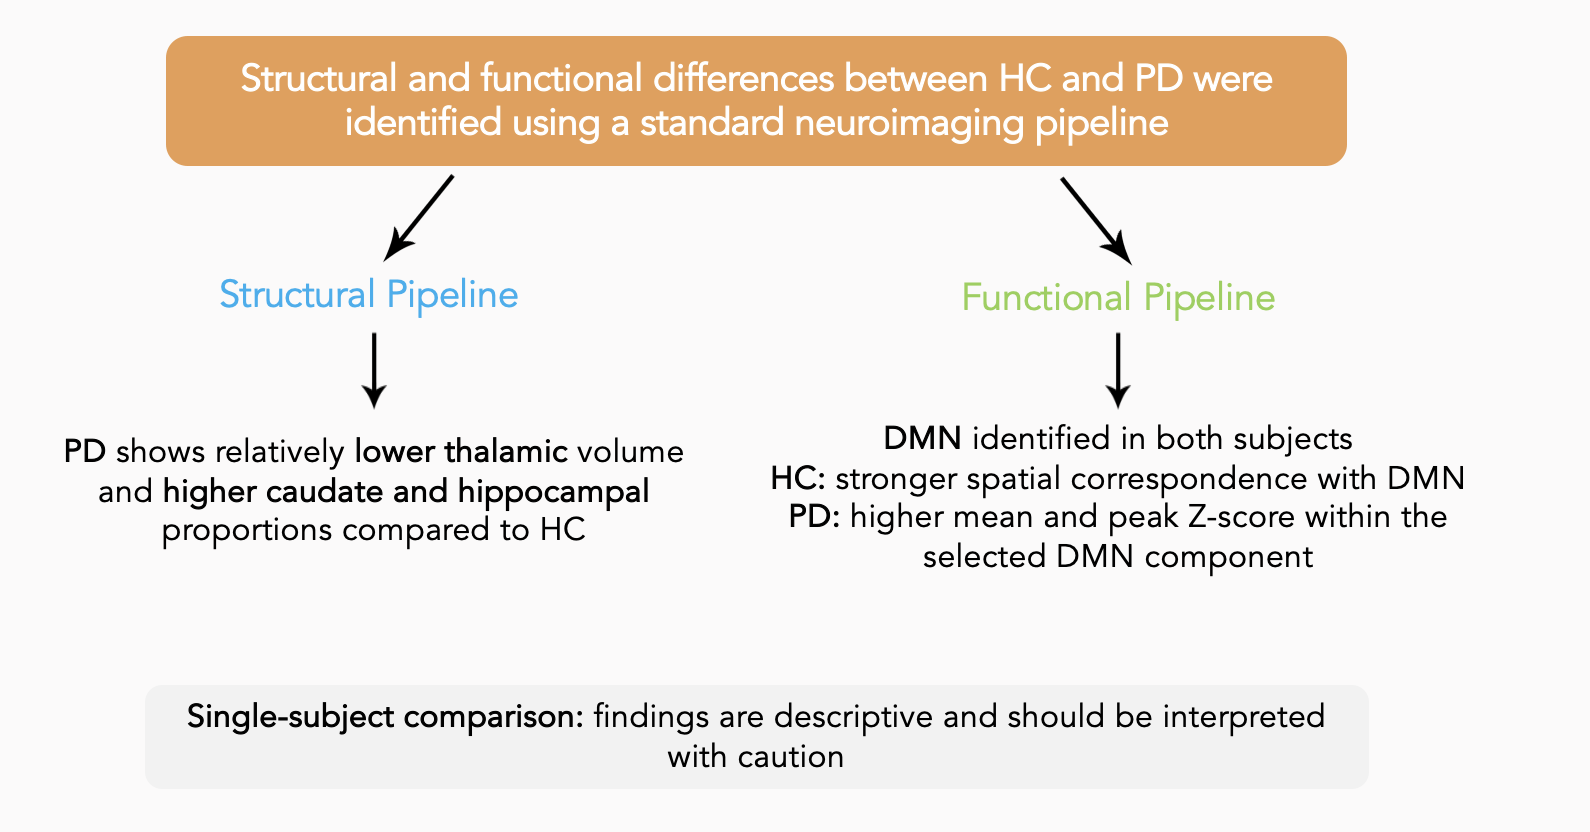